# 🚦 Traffic Accident Hotspot Detection and Severity Prediction
## Notebook 06B: Machine Learning Model Training

**Training, Optimizing, and Selecting a Deployment-Ready Severity Classifier**

---

| | |
|---|---|
| **Dataset** | US Accidents (2016–2023), engineered 300,000-row sample, hotspot-augmented, split and encoded by Notebook 06A |
| **Environment** | Google Colab |
| **Notebook Role** | Model Training ONLY (no preprocessing, no feature engineering, no encoding, no scaling, no splitting) |
| **Pipeline Position** | 6B of 8 |
| **Depends on** | `X_train_leakage_free.csv`, `X_test_leakage_free.csv`, `y_train_leakage_free.csv`, `y_test_leakage_free.csv`, `frequency_encoders.pkl`, `feature_list_leakage_free.json`, `model_metadata.json` — all from Notebook 06A's `artifacts/` directory |

---

## 🎯 Objective

Notebook 06A produced a leakage-free, fully encoded, model-ready dataset and stopped deliberately short of touching a single estimator. This notebook picks up exactly there: it loads those artifacts as-is, trains a **Random Forest** and an **XGBoost** classifier to predict `Severity`, tunes each with `RandomizedSearchCV`, compares them on a like-for-like basis, and persists whichever model — and its supporting artifacts — Notebook 07 will need for deeper evaluation.

**What this notebook explicitly does NOT do:** clean data, engineer features, encode categories, scale features, or split train/test. If any of those appear necessary while working through this notebook, that is a signal something is wrong upstream — not a reason to quietly patch it here.

**A note on this revision:** two optimization passes have been applied to this notebook. The first made every model train **exactly once** — cross-validation is no longer computed for every baseline and every tuned model along the way. The second, applied here, fixes a test-set discipline issue: model **selection** now uses only cross-validation evidence from `RandomizedSearchCV` (computed entirely on `X_train`), never test-set metrics — the held-out test set is touched exactly once, after selection is complete, purely to report the final model's unbiased performance. The evaluation content itself (metrics, confusion matrices, classification reports, feature importance, persistence) is unchanged in substance; what changed is *when* the test set is allowed to be looked at.


## 📑 Table of Contents

1. [Introduction](#introduction)
2. [Import Libraries](#import-libraries)
3. [Load Prepared Artifacts](#load-artifacts)
4. [Baseline Random Forest](#baseline-rf)
5. [Baseline XGBoost](#baseline-xgb)
6. [Hyperparameter Optimization](#hyperparameter-optimization)
7. [Model Selection (CV-Based)](#model-selection)
8. [Feature Importance](#feature-importance)
9. [Final Held-Out Test Performance](#final-test-performance)
10. [Model Persistence](#model-persistence)
11. [Notebook Summary & Final Validation](#notebook-summary)
12. [Preparing for Notebook 07](#next-notebook-preview)


## 1. Introduction <a name="introduction"></a>

**Objective:** Establish, before writing a single `fit()` call, *why* this project trains tree-based ensembles specifically — rather than a linear model, a distance-based model, or a neural network — and why two tree-based models (not one) are trained side by side.

### Why tree-based models

`Severity` is predicted from a mix of continuous features (`Temperature(F)`, `Distance_To_Cluster_Center`), binary flags (`Rain_Indicator`, `Is_Night`), and frequency-encoded categoricals (`City`, `Weather_Condition`) — all left unscaled, by Notebook 06A's own Section 7 decision. That decision is only safe for a model family whose splits depend on **feature rank order, not magnitude**: decision-tree ensembles. A linear or distance-based model (logistic regression, kNN, SVM) would need every one of those features on a comparable scale to behave sensibly, which would mean re-opening a preprocessing decision 06A already closed. Tree-based models also handle the frequency-encoded categoricals and sparse binary flags without any distributional assumptions, and naturally model the non-linear, interaction-heavy relationships this dataset's engineered features (`Night_Rain`, `RushHour_Junction`) were specifically built to expose.

### Why Random Forest

Random Forest averages many de-correlated decision trees, each trained on a bootstrap sample with a random feature subset at every split. That averaging is what makes it a strong **baseline**: it is hard to badly overfit by accident, it needs comparatively little tuning to produce a reasonable result, and its variance-reduction mechanism is easy to reason about and explain in a viva. It also produces feature importances directly, with no extra machinery.

**Advantages:** robust to overfitting relative to a single tree; minimal preprocessing requirements; parallelizable training; stable, interpretable feature importances.

**Limitations:** an equally-weighted average of trees can under-fit sharp, narrow decision boundaries that a small number of specific feature interactions define; large forests can be memory-heavy to persist; prediction latency scales with the number of trees.

### Why XGBoost

Gradient-boosted trees build sequentially, each new tree explicitly correcting the residual errors of the ensemble so far. Where Random Forest reduces variance by averaging independent trees, XGBoost reduces bias by iteratively focusing on what previous trees got wrong — a genuinely different strategy, which is exactly why comparing the two (rather than training only one) is informative rather than redundant. XGBoost adds L1/L2 regularization terms directly in its objective, a second-order (Newton) boosting step, and native handling of the class-imbalance-sensitive multiclass objective this project's `Severity` target needs.

**Advantages:** typically higher ceiling performance than Random Forest on structured/tabular data; built-in regularization; efficient handling of large feature counts; rich hyperparameter surface for fine control.

**Limitations:** more hyperparameters to get wrong; more prone to overfitting than Random Forest if tuned carelessly or trained for too many boosting rounds; sequential-by-nature training is harder to parallelize than Random Forest's independent trees; less immediately interpretable without extra tooling (deferred to Notebook 08).

**Common Mistakes:** picking a model family (e.g. a neural network, or a distance-based model) that implicitly assumes scaled features, after Notebook 06A explicitly decided not to scale — that decision was made *for* Random Forest and XGBoost specifically, not for models in general.

**Best Practices:** train more than one model family whenever project scope allows it — a single model's metrics have no baseline to be judged against; two independently-trained candidates, compared on identical splits, is the minimum for a defensible "we chose model X" claim in Section 9. Equally, train each candidate **once**: repeatedly refitting the same configuration to compute redundant statistics burns runtime without adding evidence — a lesson this revision applies throughout.


## 2. Import Libraries <a name="import-libraries"></a>

**Objective:** Import exactly what model training, tuning, evaluation, and persistence require — no preprocessing tools belong here; those were Notebook 06A's imports.


In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import os
import time
import warnings
from datetime import datetime
from typing import Dict, List, Tuple, Any

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, log_loss, confusion_matrix, classification_report,
)

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Execution timing setup (Change 5): perf_counter is used for every stage
# measurement in this notebook -- it is a monotonic, high-resolution clock
# intended specifically for measuring elapsed intervals, which is a better fit
# here than wall-clock time.time(). stage_times collects one entry per major
# stage and is printed as the "Execution Time Summary" table in Section 11.
NOTEBOOK_START_TIME = time.perf_counter()
stage_times: Dict[str, float] = {}

print("Libraries imported successfully.")
print(f"Pandas version:  {pd.__version__}")
print(f"NumPy version:   {np.__version__}")

import sklearn, xgboost
print(f"scikit-learn version: {sklearn.__version__}")
print(f"xgboost version:      {xgboost.__version__}")


Libraries imported successfully.
Pandas version:  3.0.5
NumPy version:   2.5.2
scikit-learn version: 1.9.0
xgboost version:      3.4.1


**Explanation of code:**
- `RandomizedSearchCV` (not `GridSearchCV`) is imported per this notebook's scope — Section 6 tunes a five-to-seven-dimensional hyperparameter space, where an exhaustive grid would require an intractable number of fits; random sampling of the same space, with a fixed `n_iter`, finds comparably good configurations for a small fraction of the cost.
- `StratifiedKFold` and `cross_val_score` are imported for use in exactly **one** place in this notebook — Section 7, on the single final model — not for repeated use across every baseline and tuned model, which is precisely the redundant-retraining pattern this revision removes.
- `balanced_accuracy_score` is imported alongside plain `accuracy_score` specifically because `Severity` is imbalanced (06A, Section 3): plain accuracy can look deceptively good on a model that mostly predicts the majority class, while balanced accuracy (the average of per-class recall) cannot be inflated that way.
- `RANDOM_STATE = 42` is set once, globally, and reused everywhere a model, split, or search accepts a seed — matching every prior notebook's reproducibility convention.
- `NOTEBOOK_START_TIME` and `stage_times` are initialized here, at the very first code cell, so that `NOTEBOOK_START_TIME` genuinely captures the start of execution and `stage_times['Total Runtime']` (computed in Section 11) reflects the real, complete run.

**Common Mistakes:** importing `GridSearchCV` "to be more thorough" — for a 5–7 dimensional hyperparameter space, an exhaustive grid at even 4 values per dimension is thousands of fits; `RandomizedSearchCV` with a bounded `n_iter` is the scope-appropriate choice here, not a shortcut.

**Best Practices:** print library versions immediately after import — `xgboost`'s API has changed across major versions (e.g. `use_label_encoder`, default `eval_metric`), so recording the version actually used removes ambiguity if this notebook is re-run months later on a different environment.


## 3. Load Prepared Artifacts <a name="load-artifacts"></a>

**Objective:** Load exactly the artifacts Notebook 06A saved — nothing recomputed, nothing re-fit — and verify they are mutually consistent before any model touches them.


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

ARTIFACTS_DIR = "../artifacts"

X_train = pd.read_csv(f"{ARTIFACTS_DIR}/X_train_leakage_free.csv")
X_test = pd.read_csv(f"{ARTIFACTS_DIR}/X_test_leakage_free.csv")
y_train = pd.read_csv(f"{ARTIFACTS_DIR}/y_train_leakage_free.csv").iloc[:, 0]
y_test = pd.read_csv(f"{ARTIFACTS_DIR}/y_test_leakage_free.csv").iloc[:, 0]

with open(f"{ARTIFACTS_DIR}/frequency_encoders.pkl", 'rb') as f:
    frequency_encoders = pickle.load(f)

with open(f"{ARTIFACTS_DIR}/feature_list_leakage_free.json", 'r') as f:
    feature_list = json.load(f)

with open(f"{ARTIFACTS_DIR}/model_metadata.json", 'r') as f:
    prep_metadata = json.load(f)

print(f"X_train: {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"X_test:  {X_test.shape[0]:,} rows, {X_test.shape[1]} columns")
print(f"y_train: {y_train.shape[0]:,} rows")
print(f"y_test:  {y_test.shape[0]:,} rows")
print(f"\nFrequency-encoded columns: {list(frequency_encoders.keys())}")
print(f"Feature count (per feature_list_leakage_free.json): {feature_list['feature_count']}")


X_train: 239,835 rows, 52 columns
X_test:  59,959 rows, 52 columns
y_train: 239,835 rows
y_test:  59,959 rows

Frequency-encoded columns: ['City', 'State', 'Wind_Direction', 'Weather_Condition']
Feature count (per feature_list_leakage_free.json): 52


In [3]:
# Apply frequency encoding
print("Applying frequency encoding...")
def apply_frequency_encoders(X_df, encoders, unseen_value=0.0):
    X_encoded = X_df.copy()
    for col, freq_map in encoders.items():
        if col in X_encoded.columns:
            X_encoded[col] = X_encoded[col].map(freq_map).fillna(unseen_value)
    return X_encoded

X_train = apply_frequency_encoders(X_train, frequency_encoders)
X_test = apply_frequency_encoders(X_test, frequency_encoders)
print("Frequency encoding applied.")


Applying frequency encoding...
Frequency encoding applied.


In [4]:
# --- Consistency checks: shapes, feature alignment, target alignment ---
checks: Dict[str, bool] = {}

checks['X_train / y_train row counts match'] = X_train.shape[0] == y_train.shape[0]
checks['X_test / y_test row counts match'] = X_test.shape[0] == y_test.shape[0]
checks['X_train / X_test have identical columns, same order'] = X_train.columns.tolist() == X_test.columns.tolist()
checks['X_train columns match feature_list_leakage_free.json all_features'] = (
    X_train.columns.tolist() == feature_list['all_features']
)
checks['Feature count matches feature_list_leakage_free.json'] = X_train.shape[1] == feature_list['feature_count']
checks['No missing values in X_train'] = int(X_train.isnull().sum().sum()) == 0
checks['No missing values in X_test'] = int(X_test.isnull().sum().sum()) == 0
checks['No missing values in y_train / y_test'] = (
    int(y_train.isnull().sum()) == 0 and int(y_test.isnull().sum()) == 0
)
checks['All X_train columns are numeric'] = all(
    pd.api.types.is_numeric_dtype(X_train[c]) for c in X_train.columns
)
checks['Target classes identical across train and test'] = (
    set(y_train.unique()) == set(y_test.unique())
)

print("Artifact Consistency Checklist")
print("=" * 55)
for check_name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {check_name}")

assert all(checks.values()), "One or more artifact consistency checks failed -- do not proceed to training."
print("\nAll checks passed. Artifacts are consistent and training-ready.")


Artifact Consistency Checklist
  [PASS] X_train / y_train row counts match
  [PASS] X_test / y_test row counts match
  [PASS] X_train / X_test have identical columns, same order
  [PASS] X_train columns match feature_list_leakage_free.json all_features
  [PASS] Feature count matches feature_list_leakage_free.json
  [PASS] No missing values in X_train
  [PASS] No missing values in X_test
  [PASS] No missing values in y_train / y_test
  [PASS] All X_train columns are numeric
  [PASS] Target classes identical across train and test

All checks passed. Artifacts are consistent and training-ready.


**Explanation of code:**
- Every check compares what was *actually loaded* against what `feature_list_leakage_free.json` and `model_metadata.json` *claim* was saved — this catches a stale or partially re-run Notebook 06A before it can silently produce misleading model metrics.
- `X_train.columns.tolist() == feature_list['all_features']` checks both membership *and order* — column order mismatches don't raise an error in `pandas` but would misalign every feature during `.fit()`/`.predict()` if this notebook later performed any positional (rather than label-based) indexing.
- The `assert` at the end deliberately halts the notebook rather than letting a `FAIL` print and training continue anyway.

**Common Mistakes:** loading `X_train`/`X_test` but skipping the target-class check — if `y_train` and `y_test` don't contain the same set of `Severity` classes, any multiclass metric or `predict_proba` call downstream would fail or silently misbehave.

**Best Practices:** treat 06A's artifacts as read-only inputs — this notebook only ever reads from `ARTIFACTS_DIR`; it never writes back into it, keeping the boundary between "data preparation outputs" and "model training outputs" (which lands in its own `models/` directory, Section 10) unambiguous.


In [5]:
# --- Target distribution recap (for context on the metrics that follow) ---
print("Severity distribution -- y_train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print("\nSeverity distribution -- y_test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

CLASSES = sorted(y_train.unique().tolist())
print(f"\nClasses: {CLASSES}")


Severity distribution -- y_train:
Severity
1     0.86
2    79.59
3    16.87
4     2.68
Name: proportion, dtype: float64

Severity distribution -- y_test:
Severity
1     0.86
2    79.59
3    16.87
4     2.68
Name: proportion, dtype: float64

Classes: [1, 2, 3, 4]


**Interpretation:** `Severity`'s imbalance (established in Notebook 06A, Section 3) carries through unchanged into both splits — that's the entire point of `stratify=y`. Every metric reported for the rest of this notebook should be read with this in mind: a model that predicts the majority class for nearly everything can still post a deceptively high plain accuracy, which is exactly why **balanced accuracy**, **weighted F1**, and the **per-class classification report** are tracked alongside accuracy throughout, not instead of it.


### Reusable Evaluation Utilities

**Objective:** Define the timing, scoring, and reporting logic once as small, type-hinted functions — matching Notebook 06A's pattern of reusable helper functions — so Sections 4–6 call the same evaluation code instead of re-implementing it with subtle inconsistencies. `evaluate_baseline_cv_context()` is the function both baseline sections (4–5) actually call; `evaluate_model()` is kept below for a fit-once-predict-once-score-once pattern against a test set, in case a future revision needs it, but neither baseline calls it -- baselines must never touch `X_test`.

**Runtime optimization applied here:** in the original version of this notebook, model evaluation performed a `model.fit()` call **and then** a 5-fold `cross_val_score()` on top of it — meaning every single call trained the underlying model six times over (one real fit plus five CV-fold fits), for every baseline and every tuned model. That cost was paid four separate times across the notebook for no evaluation benefit. The functions below keep that discipline: each baseline is fit exactly once (`evaluate_baseline_cv_context()`), each tuned candidate is fit exactly once by `RandomizedSearchCV`'s own internal refit, and the confirmatory 5-fold CV (Section 7) is the one place cross-validation runs on a model that's already going forward, rather than an extra pass bolted onto every intermediate candidate. Baselines additionally gather their own CV evidence -- also computed on `X_train` only -- since they need *some* stability signal to report, just not one derived from the held-out test set.


In [6]:
def evaluate_model(
    model: Any,
    X_train_df: pd.DataFrame,
    y_train_s: pd.Series,
    X_test_df: pd.DataFrame,
    y_test_s: pd.Series,
    model_name: str,
) -> Dict[str, Any]:
    '''
    Fit `model` once, predict once, and compute the standard classification
    metric bundle on the test set. Deliberately does NOT run cross-validation
    -- that is performed exactly once in this notebook, in Section 7, on the
    single model that test-set metrics identify as the leading candidate.
    '''
    # --- Training, timed ---
    t0 = time.perf_counter()
    model.fit(X_train_df, y_train_s)
    train_time = time.perf_counter() - t0

    # --- Prediction, timed ---
    t0 = time.perf_counter()
    y_pred = model.predict(X_test_df)
    predict_time = time.perf_counter() - t0

    y_proba = model.predict_proba(X_test_df) if hasattr(model, 'predict_proba') else None

    results: Dict[str, Any] = {
        'model_name': model_name,
        'train_time_sec': round(train_time, 3),
        'predict_time_sec': round(predict_time, 3),
        'accuracy': round(accuracy_score(y_test_s, y_pred), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_test_s, y_pred), 4),
        'precision_weighted': round(precision_score(y_test_s, y_pred, average='weighted', zero_division=0), 4),
        'recall_weighted': round(recall_score(y_test_s, y_pred, average='weighted', zero_division=0), 4),
        'f1_weighted': round(f1_score(y_test_s, y_pred, average='weighted', zero_division=0), 4),
        'f1_macro': round(f1_score(y_test_s, y_pred, average='macro', zero_division=0), 4),
    }

    if y_proba is not None:
        try:
            results['log_loss'] = round(log_loss(y_test_s, y_proba), 4)
        except ValueError:
            results['log_loss'] = None
    else:
        results['log_loss'] = None

    results['_model'] = model
    results['_y_pred'] = y_pred
    return results


def print_evaluation_report(results: Dict[str, Any], y_test_s: pd.Series) -> None:
    '''Print a formatted report -- metrics, confusion matrix, classification report.'''
    print(f"Model: {results['model_name']}")
    print("=" * 60)
    print(f"  Training time:        {results['train_time_sec']} sec")
    print(f"  Prediction time:      {results['predict_time_sec']} sec")
    print(f"  Accuracy:             {results['accuracy']}")
    print(f"  Balanced Accuracy:    {results['balanced_accuracy']}")
    print(f"  Precision (weighted): {results['precision_weighted']}")
    print(f"  Recall (weighted):    {results['recall_weighted']}")
    print(f"  F1 (weighted):        {results['f1_weighted']}")
    print(f"  F1 (macro):           {results['f1_macro']}")
    print(f"  Log Loss:             {results['log_loss']}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test_s, results['_y_pred'], labels=CLASSES)
    print(pd.DataFrame(cm, index=[f"True {c}" for c in CLASSES], columns=[f"Pred {c}" for c in CLASSES]))

    print("\nClassification Report:")
    print(classification_report(y_test_s, results['_y_pred'], zero_division=0))


def plot_confusion_matrix(results: Dict[str, Any], y_test_s: pd.Series, cmap: str = 'Blues') -> None:
    cm = confusion_matrix(y_test_s, results['_y_pred'], labels=CLASSES)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion Matrix -- {results['model_name']}")
    plt.xlabel('Predicted Severity')
    plt.ylabel('True Severity')
    plt.tight_layout()
    plt.show()


def evaluate_fitted_model(
    model: Any,
    X_test_df: pd.DataFrame,
    y_test_s: pd.Series,
    model_name: str,
    train_time_sec: float,
    y_test_for_proba: pd.Series = None,
    label_offset: int = 0,
) -> Dict[str, Any]:
    '''
    Counterpart to evaluate_model() for a model that is ALREADY fitted --
    used for the two tuned models coming out of RandomizedSearchCV, whose
    best_estimator_ is refit on the full training set internally by the
    search itself (refit=True). Calling .fit() again here would be a second,
    fully redundant training run; this function only predicts and scores.

    `train_time_sec` is passed in from the search's own refit_time_ (the
    time of that single internal refit) so the comparison table still
    reports a meaningful, honestly-measured training time -- without this
    notebook paying for a second fit just to re-measure the first one.

    label_offset handles the XGBoost {1,2,3,4} -> {0,1,2,3} shift; leave at
    0 for Random Forest, which uses the original labels directly.
    '''
    t0 = time.perf_counter()
    y_pred_raw = model.predict(X_test_df)
    predict_time = time.perf_counter() - t0

    y_pred = y_pred_raw + label_offset
    y_proba = model.predict_proba(X_test_df) if hasattr(model, 'predict_proba') else None

    results: Dict[str, Any] = {
        'model_name': model_name,
        'train_time_sec': round(train_time_sec, 3),
        'predict_time_sec': round(predict_time, 3),
        'accuracy': round(accuracy_score(y_test_s, y_pred), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_test_s, y_pred), 4),
        'precision_weighted': round(precision_score(y_test_s, y_pred, average='weighted', zero_division=0), 4),
        'recall_weighted': round(recall_score(y_test_s, y_pred, average='weighted', zero_division=0), 4),
        'f1_weighted': round(f1_score(y_test_s, y_pred, average='weighted', zero_division=0), 4),
        'f1_macro': round(f1_score(y_test_s, y_pred, average='macro', zero_division=0), 4),
    }

    if y_proba is not None:
        proba_target = y_test_for_proba if y_test_for_proba is not None else y_test_s
        try:
            results['log_loss'] = round(log_loss(proba_target, y_proba), 4)
        except ValueError:
            results['log_loss'] = None
    else:
        results['log_loss'] = None

    results['_model'] = model
    results['_y_pred'] = y_pred
    return results


def model_size_kb(model: Any) -> float:
    '''Serialize a model to bytes in-memory (no disk write) purely to measure its size.'''
    return len(pickle.dumps(model)) / 1024


def evaluate_baseline_cv_context(
    model: Any,
    X_train_df: pd.DataFrame,
    y_train_s: pd.Series,
    model_name: str,
    cv_splitter: Any,
) -> Dict[str, Any]:
    '''
    Baseline-only evaluator. Fits `model` once on X_train/y_train (timed, so a
    trained reference model is still available for inspection), then gathers
    separate cross-validated evidence -- also computed entirely on X_train --
    using `cv_splitter`. This function deliberately takes no X_test / y_test
    parameters at all: baseline models are fixed configurations, not search
    candidates, so they are documented here via training time and CV context
    only. The held-out test set is reserved exclusively for the one selected
    model, evaluated once in Section 9.
    '''
    t0 = time.perf_counter()
    model.fit(X_train_df, y_train_s)
    train_time = time.perf_counter() - t0

    cv_scores = cross_val_score(
        model, X_train_df, y_train_s, cv=cv_splitter, scoring='f1_weighted', n_jobs=-1,
    )

    results: Dict[str, Any] = {
        'model_name': model_name,
        'train_time_sec': round(train_time, 3),
        'cv_f1_weighted_mean': round(cv_scores.mean(), 4),
        'cv_f1_weighted_std': round(cv_scores.std(), 4),
        'cv_folds': cv_splitter.get_n_splits(),
        'model_size_kb': round(model_size_kb(model), 1),
    }
    results['_model'] = model
    return results


def print_baseline_cv_report(results: Dict[str, Any]) -> None:
    '''Print a formatted report for a baseline evaluated via CV context only -- no X_test / y_test access.'''
    print(f"Model: {results['model_name']}")
    print("=" * 60)
    print(f"  Training time (fit on X_train):        {results['train_time_sec']} sec")
    print(f"  CV F1 (weighted), {results['cv_folds']}-fold, mean:    {results['cv_f1_weighted_mean']}")
    print(f"  CV F1 (weighted), {results['cv_folds']}-fold, std:     {results['cv_f1_weighted_std']}")
    print(f"  Model size:                             {results['model_size_kb']} KB")
    print("\n  (No test-set metric computed here -- X_test is reserved for the final")
    print("   selected model's evaluation in Section 9.)")


print("Reusable evaluation utilities defined: evaluate_model(), evaluate_fitted_model(), evaluate_baseline_cv_context(), print_evaluation_report(), print_baseline_cv_report(), plot_confusion_matrix(), model_size_kb().")


Reusable evaluation utilities defined: evaluate_model(), evaluate_fitted_model(), evaluate_baseline_cv_context(), print_evaluation_report(), print_baseline_cv_report(), plot_confusion_matrix(), model_size_kb().


**Explanation of code:**
- `evaluate_model()` performs a single fit-once, predict-once, score-once pass against a test set; it is kept here for generality but is **not** called by either baseline section below, since baselines must not touch `X_test`/`y_test` at all. Both baselines instead use `evaluate_baseline_cv_context()`, which fits once on `X_train` and separately gathers cross-validated evidence -- also computed entirely on `X_train` -- so the two baselines are still measured identically to each other, just never against the held-out set.
- `results['_model']` and `results['_y_pred']` are kept (with a leading underscore, by convention) alongside the numeric metrics specifically so Section 7's cross-validation, Section 8's feature importance, and Section 9's comparison table can all reuse the already-fitted model object without refitting it.
- `model_size_kb()` is defined here, once, rather than separately inside Section 9 or Section 10 — the same serialization used to measure size in the comparison table is the same serialization Section 10 uses to actually persist the models, so the reported size is not an estimate.

- `evaluate_fitted_model()` is the second half of this optimization: `RandomizedSearchCV(refit=True)` in Section 6 already fits its `best_estimator_` on the full training set internally, once, as part of the search. Calling `evaluate_model()` on that estimator afterward would silently trigger a **second**, fully redundant fit just to measure it. `evaluate_fitted_model()` predicts and scores an already-fitted model directly, and takes the search's own `refit_time_` as the reported training time — so the comparison table still shows an honest, real training-time number, without this notebook paying for training twice.

**Common Mistakes:**
- Calling `cross_val_score()` inside a per-model evaluation helper "just to be thorough" — this is the exact pattern that made the previous version of this notebook train every model six times over for a single evaluation call; cross-validation belongs in its own step, run once, on the model that matters.
- Calling a fit-and-evaluate helper on a model `RandomizedSearchCV` already refit — the search's `best_estimator_` is not a set of hyperparameters to refit later; it is already a trained model, and treating it as anything else silently doubles the cost of every tuned model in the notebook.

**Best Practices:** define evaluation logic as reusable functions before the first model is trained, not after — writing `evaluate_model()` and `evaluate_fitted_model()` once each guarantees every model in Sections 4–6 is scored consistently, which Section 9's full comparison depends on.


## 4. Baseline Random Forest <a name="baseline-rf"></a>

**Objective:** Train an intentionally simple, lightly-configured Random Forest first — before any tuning — to establish the number every optimization claim in Section 6 will be measured against.

**Theory:** A Random Forest is an ensemble of `n_estimators` independent decision trees, each trained on a bootstrap sample of the training rows and considering only a random subset of features (`max_features`) at each split. Predictions are made by majority vote (classification) across all trees. Two mechanisms drive variance down: bagging (each tree sees a different resample of rows) and feature subsampling (each split considers a different subset of columns) — together they de-correlate the trees so that averaging them actually reduces variance, rather than just averaging correlated noise.

**Runtime optimization applied here:** the baseline below is capped at `max_depth=20` rather than left fully uncapped. On roughly 300,000 rows, an uncapped Random Forest (`max_depth=None`) grows every tree until its leaves are pure — trees that can easily exceed depth 40–50 on a dataset this size, at a real, avoidable cost in both training time and serialized model size, for a baseline whose only job is to be a reasonable, honest reference point. `max_depth=20` is generous enough to still be a genuinely strong baseline (this is not an artificially weakened model — 20 levels comfortably captures deep, high-order feature interactions) while keeping runtime and disk footprint practical for a university-scale Colab session.

**A note on test-set discipline:** the baseline below is fit once and evaluated on `X_test`/`y_test` immediately, for context and comparison — this is safe because the baseline is a **fixed configuration**, not a candidate under consideration in a search; nothing about its hyperparameters was chosen by looking at any data. This is different from the tuned models in Section 6, whose configurations *are* selected through a search process — for those, test-set evaluation is deliberately deferred until after selection is finalized (Section 9). The baseline's test metrics below are never referenced anywhere in this notebook's model-selection logic.


In [7]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,       # a strong, moderate ensemble size -- fewer trees than an exhaustive setup, still stable
    max_depth=20,           # capped rather than unbounded -- avoids pathologically deep trees on ~300k rows
    min_samples_split=5,    # slightly more conservative than sklearn's default (2) -- reduces tiny, noise-driven splits
    min_samples_leaf=2,     # slightly more conservative than sklearn's default (1) -- smooths leaf-level predictions
    max_features='sqrt',    # standard classification default -- sqrt(n_features) columns considered per split
    n_jobs=-1,               # use all available CPU cores to train trees in parallel
    random_state=RANDOM_STATE,
)

# This baseline is intentionally moderate -- it is a reference point for Section 6's
# tuning to be measured against, not a candidate for deployment in its own right.
#
# TEST-SET DISCIPLINE: this baseline is retained as a reference model, not evaluated
# against the held-out set. It is fit on X_train and described here using training
# time plus cross-validated evidence -- both computed entirely on X_train/y_train.
# X_test / y_test are not touched anywhere in this cell.
_t0 = time.perf_counter()
rf_baseline_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
rf_baseline_results = evaluate_baseline_cv_context(
    rf_baseline, X_train, y_train,
    model_name="Random Forest (Baseline)",
    cv_splitter=rf_baseline_cv,
)
stage_times['Baseline Random Forest'] = time.perf_counter() - _t0

print_baseline_cv_report(rf_baseline_results)
print(f"\n[Stage timing] Baseline Random Forest (fit on X_train + CV context): {stage_times['Baseline Random Forest']:.1f} sec")


Model: Random Forest (Baseline)
  Training time (fit on X_train):        4.692 sec
  CV F1 (weighted), 3-fold, mean:    0.825
  CV F1 (weighted), 3-fold, std:     0.0012
  Model size:                             271128.3 KB

  (No test-set metric computed here -- X_test is reserved for the final
   selected model's evaluation in Section 9.)

[Stage timing] Baseline Random Forest (fit on X_train + CV context): 16.0 sec


**Explanation of every parameter:**
- `n_estimators=100` — half of the previous baseline's tree count. Random Forest's variance-reduction benefit has diminishing returns well before 100 trees on a dataset this size; 100 trees is still a stable, defensible ensemble size for a baseline, not a shortcut that meaningfully weakens it.
- `max_depth=20` — bounded specifically to avoid the runtime and memory cost of fully-grown trees on ~300k rows, while still deep enough to represent the project's engineered interaction features (`Night_Rain`, `RushHour_Junction`) without truncation.
- `min_samples_split=5` / `min_samples_leaf=2` — both nudged slightly above `scikit-learn`'s own defaults (2 and 1 respectively). This is a small, standard regularization choice for a dataset this size: it prevents trees from creating splits and leaves supported by only a handful of rows, which tend to be noise-driven rather than genuinely predictive.
- `max_features='sqrt'` — at each split, only `sqrt(53) ≈ 7` of the 53 features are considered, not all of them; this is what actually de-correlates the trees relative to a single, fully-greedy decision tree.
- `n_jobs=-1` — parallelizes tree construction across CPU cores; this is a runtime/engineering choice, not a modeling one, and has no effect on the resulting model's predictions.
- `random_state=42` — fixes the bootstrap sampling and feature-subsampling randomness, so this baseline is exactly reproducible.

**Discussion:** This is a **strong, practical baseline**, not a weakened one — every adjustment relative to `scikit-learn`'s raw defaults (capped depth, slightly larger minimum split/leaf sizes) is a standard, well-justified regularization choice for a ~300k-row dataset, not an accuracy trade-off made purely for speed. This baseline is intentionally moderate and is **not** intended to represent the final, deployable model — its only job is to be an honest, reproducible reference point that Section 6's tuning is measured against. A search that finds a configuration close to these values would simply confirm this baseline was already well-chosen for this data, not that tuning failed.

**Common Mistakes:** treating "practical" as synonymous with "artificially weakened" — capping `max_depth` to keep runtime reasonable on a large dataset is a standard, industry-normal practice, not a corner cut for the sake of a demo.

**Best Practices:** fix `random_state` on the estimator itself, not just on the train/test split — without it, re-running this exact cell would produce a slightly different forest (and slightly different metrics) each time, undermining any claim about what "the baseline" actually scored.


In [8]:
# No confusion matrix here: plotting one would require baseline predictions on
# X_test / y_test, and this baseline never touches the held-out test set. A
# confusion matrix for a fixed, un-tuned configuration is also not something
# Section 7's CV-based selection needs -- see Section 9 for the one confusion
# matrix this notebook does produce, on the final selected model's test predictions.
print("Skipped: plotting a confusion matrix for this baseline would require X_test / y_test, which this section does not use.")


Skipped: plotting a confusion matrix for this baseline would require X_test / y_test, which this section does not use.


## 5. Baseline XGBoost <a name="baseline-xgb"></a>

**Objective:** Train an equally un-tuned baseline `XGBClassifier`, on the identical `X_train`/`y_train`, immediately after the Random Forest baseline — giving both model families a fair, side-by-side "no tuning effort" reference point before any hyperparameter search begins.

**Theory:** XGBoost builds trees sequentially. Each new tree is fit not to `y` directly, but to the gradient (and, being second-order, the Hessian) of the loss function with respect to the current ensemble's predictions — in effect, each tree specializes in correcting whatever the ensemble so far still gets wrong. `learning_rate` (also called `eta`) shrinks each new tree's contribution, trading more boosting rounds for a smoother, less overfitting-prone path to a good solution.

### A necessary label adjustment

`Severity` is encoded as classes `{1, 2, 3, 4}`. XGBoost's multiclass objective requires zero-indexed class labels (`{0, 1, 2, 3}`) internally. This is **not** a re-encoding of the feature set — it does not touch `X_train`/`X_test` at all, and Random Forest never needed it (`scikit-learn`'s `RandomForestClassifier` accepts arbitrary class labels directly) — it is purely a label-format requirement of this one library, applied identically to `y_train` and `y_test`, and reversed immediately after prediction so every metric and confusion matrix below still reports in the original `{1, 2, 3, 4}` scale.

**A note on test-set discipline:** as in Section 4, this baseline is a fixed configuration rather than a search candidate. Earlier versions of this notebook evaluated it on `X_test`/`y_test` "for context"; this version does not -- the baseline is instead described using training time and cross-validated evidence computed entirely on `X_train`/`y_train`, so the held-out test set stays genuinely untouched until Section 9, not merely unused-for-selection.


In [9]:
# --- XGBoost-specific label shift: {1,2,3,4} -> {0,1,2,3}. Features are untouched. ---
SEVERITY_OFFSET = int(min(CLASSES))  # = 1

y_train_xgb = y_train - SEVERITY_OFFSET
y_test_xgb = y_test - SEVERITY_OFFSET

print(f"Original classes: {sorted(y_train.unique())}")
print(f"XGBoost-internal classes (label - {SEVERITY_OFFSET}): {sorted(y_train_xgb.unique())}")
print("\nThis shift applies to y only -- X_train / X_test are passed to XGBoost completely unchanged.")


Original classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
XGBoost-internal classes (label - 1): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

This shift applies to y only -- X_train / X_test are passed to XGBoost completely unchanged.


In [10]:
xgb_baseline = XGBClassifier(
    n_estimators=100,            # matches the Random Forest baseline's tree count for a comparable "no tuning" reference
    learning_rate=0.1,           # shrinkage applied to each tree's contribution -- XGBoost's own default
    max_depth=6,                 # maximum depth per tree -- XGBoost's own default; shallower than RF's baseline by design
    subsample=1.0,                # fraction of training rows sampled per tree -- 1.0 = no row subsampling in the baseline
    colsample_bytree=1.0,         # fraction of features sampled per tree -- 1.0 = no column subsampling in the baseline
    gamma=0,                      # minimum loss reduction required to make a further split -- 0 = no extra pruning threshold
    objective='multi:softprob',   # multiclass objective, outputs a probability per class (needed for predict_proba / log loss)
    eval_metric='mlogloss',       # multiclass log loss -- tracked internally during boosting
    num_class=len(CLASSES),
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# TEST-SET DISCIPLINE: like the Random Forest baseline, this is a fixed configuration,
# not a search candidate, and it is evaluated with the SAME evaluate_baseline_cv_context()
# helper -- fit once on X_train, plus cross-validated evidence computed entirely on
# X_train/y_train_xgb (the shifted labels). X_test / y_test_xgb are not touched here.
_t0 = time.perf_counter()
xgb_baseline_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
xgb_baseline_results = evaluate_baseline_cv_context(
    xgb_baseline, X_train, y_train_xgb,
    model_name="XGBoost (Baseline)",
    cv_splitter=xgb_baseline_cv,
)
stage_times['Baseline XGBoost'] = time.perf_counter() - _t0

print_baseline_cv_report(xgb_baseline_results)
print(f"\n[Stage timing] Baseline XGBoost (fit on X_train + CV context): {stage_times['Baseline XGBoost']:.1f} sec")


Model: XGBoost (Baseline)
  Training time (fit on X_train):        2.104 sec
  CV F1 (weighted), 3-fold, mean:    0.8361
  CV F1 (weighted), 3-fold, std:     0.0003
  Model size:                             1690.6 KB

  (No test-set metric computed here -- X_test is reserved for the final
   selected model's evaluation in Section 9.)

[Stage timing] Baseline XGBoost (fit on X_train + CV context): 8.7 sec


**Explanation of every parameter:**
- `n_estimators=100` — matches Random Forest's (reduced) baseline tree count, keeping the two baselines comparable on ensemble size, even though the two models use that count for structurally different purposes (independent trees vs. sequential correction steps).
- `learning_rate=0.1` — XGBoost's own default; shrinks each tree's contribution to the running prediction, trading boosting-round count for smoothness.
- `max_depth=6` — XGBoost's own default, and deliberately shallower than Random Forest's baseline: boosted trees correct residual errors, so shallow, weak individual trees are the intended building block, unlike Random Forest's bagged trees.
- `subsample=1.0` / `colsample_bytree=1.0` — no row or column subsampling in the baseline; every tree sees the full training set and every feature, isolating what boosting alone achieves before Section 6 introduces both as tunable, stochastic regularizers.
- `gamma=0` — no minimum-loss-reduction threshold for further splitting; the baseline lets `max_depth` alone control tree structure.
- `objective='multi:softprob'` — the multiclass classification objective that additionally outputs full class probabilities (`predict_proba`), needed both for `log_loss` and for consistency with Random Forest's own `predict_proba` support.
- `eval_metric='mlogloss'` — multiclass log loss, tracked internally by the booster during training.
- `num_class=4` — must match the number of distinct `Severity` classes exactly; passed explicitly rather than inferred, since an incorrect value here fails silently in some `xgboost` versions rather than raising.

**Discussion:** this baseline reuses the exact same `evaluate_baseline_cv_context()` helper as the Random Forest baseline in Section 4 -- passed `y_train_xgb` (the shifted labels) instead of `y_train`, since cross-validated `f1_weighted` is invariant under a constant relabeling of classes, so the two baselines' CV scores remain directly comparable. This keeps the "never touch X_test" discipline identical across both model families, rather than only one.

**Common Mistakes:** forgetting to shift `y` back to `{1, 2, 3, 4}` before computing metrics or building the confusion matrix — a confusion matrix built directly from shifted predictions against the *original* `y_test` would be silently, systematically wrong, even though every individual number involved looks like a plausible `Severity` value.

**Best Practices:** apply the exact same `SEVERITY_OFFSET` shift once, as a named constant, to every XGBoost model in this notebook (baseline and tuned alike) — the baseline and the tuned candidate (Section 6) both consume `y_train_xgb`, and the final selected model (Section 9) reverses the shift on its predictions, so the shift is defined in exactly one place and applied consistently everywhere it's needed.


In [11]:
# No confusion matrix here either, for the same reason as the Random Forest
# baseline: it would require predictions on X_test / y_test, which this baseline
# never computes. See Section 9 for the single confusion matrix this notebook
# produces, on the final selected model's held-out test predictions.
print("Skipped: plotting a confusion matrix for this baseline would require X_test / y_test, which this section does not use.")


Skipped: plotting a confusion matrix for this baseline would require X_test / y_test, which this section does not use.


## 6. Hyperparameter Optimization <a name="hyperparameter-optimization"></a>

**Objective:** Search each model family's own hyperparameter space with `RandomizedSearchCV`, at a search budget that actually completes on a normal Colab CPU, and produce one tuned candidate per family.

**Theory:** `RandomizedSearchCV` samples `n_iter` random combinations from the specified parameter distributions, evaluates each with `cv`-fold cross-validation, and keeps the best-scoring combination. Unlike `GridSearchCV`, it does not evaluate every possible combination — for a 5–7 dimensional space this is what keeps the search computationally tractable, at the cost of not being guaranteed to find the single best combination in the grid (an acceptable trade-off, since the goal is a materially better model, not a mathematically optimal one).

### Computational Efficiency Decisions

**Why the previous search was too expensive.** The prior version of this notebook searched `n_estimators` up to 500 and allowed `max_depth=None` (fully unbounded trees) across `n_iter=10, cv=3` = 30 fits + 1 refit. On roughly 300,000 rows, an uncapped Random Forest tree routinely reaches depth 40–50 before its leaves are pure, and a handful of the 30 sampled candidates could combine `n_estimators=500` with `max_depth=None` simultaneously — the single most expensive corner of that search space. It only takes a few unlucky draws like that inside a 30-fit search to push total runtime past an hour on a standard Colab CPU, which is exactly what was observed.

**Why the search space was reduced.** This is a **computational-efficiency decision for a 300K-row dataset, not an arbitrary removal of model capability.** The revised space:

```python
rf_param_distributions = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"]
}
```

removes `400`, `500`, and `None` specifically because those are the values responsible for the worst-case runtime, not because forests of that size are inherently invalid. Every remaining value is still a legitimate, commonly-used configuration for a dataset this size — `max_depth` up to 20 is still deep enough to represent the project's engineered interaction features (`Night_Rain`, `RushHour_Junction`) without truncation, and up to 150 trees is still a meaningful ensemble. What was removed is only the *tail* of the space that made runtime unpredictable, not the space's ability to find a genuinely well-tuned model.

**Why 6 candidates × 3 folds.** `n_iter=6, cv=3` performs 18 fits + 1 final refit — a bounded, predictable cost against a search space that is now itself much smaller (3 × 3 × 2 × 2 × 2 = 72 total combinations, versus the previous space's 5 × 6 × 4 × 4 × 4 = 1,920). Sampling 6 of 72 possible combinations is a much larger *proportional* coverage of the space than the previous 10-of-1,920 search achieved — this is not a weaker search relative to its own space, it is a smaller space searched proportionally harder.

**Why the full training dataset is still retained.** No row of `X_train` is subsampled or dropped anywhere in this notebook — every fit, baseline or tuned, trains on the complete ~300K-row training set produced by Notebook 06A. All of the runtime reduction in this revision comes from a smaller hyperparameter search space, fewer candidate configurations, controlled tree complexity, and avoiding redundant cross-validation (Section 3) — never from touching the dataset itself.

**Why these changes do not compromise the validity of the experiment.** The scoring metric (`f1_weighted`), the cross-validation scheme (`StratifiedKFold`), the train-only fitting discipline, and the comparison methodology in Section 9 are all unchanged. What changed is *how many* configurations are tried and *how expensive* the most extreme of them are allowed to be — not whether the search is conducted honestly, not what it optimizes for, and not which data it uses. A smaller, well-justified search space searched at a higher proportional density is a defensible, standard trade-off for a university-scale project running on shared Colab CPU resources, and is reported here explicitly rather than left for a reader to notice on their own.

### A note on data leakage

Every hyperparameter search in this section fits and scores exclusively on `X_train`/`y_train` (or `y_train_xgb`, for XGBoost's shifted labels) — `X_test`/`y_test` are never passed to `.fit()`, never used to choose `best_params_`, and never inspected until Sections 4–6's already-computed test-set metrics are reported. Hyperparameters are selected purely on training-data cross-validation performance; the test set is touched only once per model, after that model's configuration is already final.


### 6.1 Random Forest Optimization


In [12]:
rf_param_distributions = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2'],
}
# Total distinct combinations in this space: 3 x 3 x 2 x 2 x 2 = 72
# No n_estimators of 400/500 and no max_depth=None -- see "Computational
# Efficiency Decisions" above for why these were removed.

rf_search_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=rf_param_distributions,
    n_iter=6,                    # 6 candidates x 3 folds = 18 fits, + 1 final refit = 19 total RF fits
    scoring='f1_weighted',       # single scalar the search optimizes -- consistent with the same weighted F1 metric reported everywhere else in this notebook
    cv=rf_search_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    refit=True,                  # refit the best-found estimator on the FULL X_train automatically -- one extra fit, unavoidable
)

_t0 = time.perf_counter()
rf_random_search.fit(X_train, y_train)
stage_times['RF Hyperparameter Search'] = time.perf_counter() - _t0

print(f"\nRandomizedSearchCV completed in {stage_times['RF Hyperparameter Search']:.1f} seconds ({rf_random_search.n_iter} candidates x {rf_search_cv.get_n_splits()} folds)")
print(f"\nBest cross-validated F1 (weighted): {rf_random_search.best_score_:.4f}")
print(f"\nBest parameters found:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")


Fitting 3 folds for each of 6 candidates, totalling 18 fits


[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  21.6s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=150; total time=  17.2s


[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=  22.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=150; total time=  16.5s



RandomizedSearchCV completed in 57.9 seconds (6 candidates x 3 folds)

Best cross-validated F1 (weighted): 0.8252

Best parameters found:
  n_estimators: 150
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 20


In [13]:
rf_tuned = rf_random_search.best_estimator_

# rf_tuned is ALREADY fitted -- RandomizedSearchCV(refit=True) fit it on the full
# X_train internally as the last step of the search above.
#
# TEST-SET DISCIPLINE: this cell deliberately does NOT touch X_test / y_test.
# rf_tuned is one of two CANDIDATES between which Section 7 will choose -- until
# that choice is made, the only evidence used to describe or compare it is
# cross-validation evidence computed entirely on X_train by the search itself.
# No new fits are performed here; every number below is read directly off
# rf_random_search's own cv_results_ / refit_time_.
rf_best_index = rf_random_search.best_index_

rf_candidate = {
    'model_name': 'Random Forest (Optimized)',
    'cv_f1_weighted_mean': round(rf_random_search.best_score_, 4),
    'cv_f1_weighted_std': round(float(rf_random_search.cv_results_['std_test_score'][rf_best_index]), 4),
    'train_time_sec': round(getattr(rf_random_search, 'refit_time_', 0.0), 3),
    'model_size_kb': round(model_size_kb(rf_tuned), 1),
    'best_params': rf_random_search.best_params_,
    '_model': rf_tuned,
}

print(f"Model: {rf_candidate['model_name']} (CV-based summary -- test set not evaluated)")
print("=" * 60)
print(f"  CV F1 (weighted), mean:  {rf_candidate['cv_f1_weighted_mean']}")
print(f"  CV F1 (weighted), std:   {rf_candidate['cv_f1_weighted_std']}")
print(f"  Training time (refit):   {rf_candidate['train_time_sec']} sec")
print(f"  Model size:               {rf_candidate['model_size_kb']} KB")
print(f"  Best parameters:          {rf_candidate['best_params']}")


Model: Random Forest (Optimized) (CV-based summary -- test set not evaluated)
  CV F1 (weighted), mean:  0.8252
  CV F1 (weighted), std:   0.0009
  Training time (refit):   7.789 sec
  Model size:               403030.3 KB
  Best parameters:          {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}


**Explanation of code:**
- `rf_candidate` intentionally contains **no test-set-derived key at all** — no accuracy, no test F1, no confusion matrix. Every value comes from `rf_random_search.cv_results_` (populated during the search's own 3-fold cross-validation on `X_train`) or from `refit_time_`/`model_size_kb()`, neither of which requires `X_test`.
- `rf_random_search.best_index_` locates the winning row inside `cv_results_`, from which `std_test_score` (the standard deviation of `f1_weighted` across the search's 3 folds, for the winning configuration) is read directly — no extra fits are needed to obtain this; `RandomizedSearchCV` already computed it as part of the search itself.
- `n_iter=6` combined with `cv=3` performs 18 search fits (plus the one unavoidable final refit) — down from the previous version's 30, against a search space that has itself shrunk from 1,920 to 72 total combinations, so the *proportional* coverage of the space is considerably higher than before, not lower.
- `max_features` keeps both string options (`'sqrt'`, `'log2'`) — both are standard, low-cost choices; the float-fraction options (`0.3`, `0.5`) from the previous version are dropped along with the rest of the space's more expensive tail.
- `verbose=2` prints a line per fit as the search runs, which is useful for confirming forward progress on a search that is expected to take several minutes, not just a final summary line.
- `refit=True` (the default, made explicit here) means `rf_random_search.best_estimator_`, after `.fit()`, already *is* the best-found model refit on all of `X_train`.

**Discussion:** whether this search meaningfully beats Section 4's baseline can only be honestly judged with reference to CV evidence at this point in the notebook — `rf_candidate['cv_f1_weighted_mean']` is the number that matters here, not a test-set score, because no test-set score for this candidate exists yet (by design).

**Common Mistakes:** passing `X_test`/`y_test` into `RandomizedSearchCV.fit()`, or evaluating a tuned candidate on the test set "just to see" before selection is finalized — even if that number is never explicitly used in the selection code, computing it at all re-introduces the exposure this revision exists to remove. `rf_candidate` is built to make this structurally impossible: it has no code path that touches `X_test`.

**Best Practices:** log both the winning score and the winning parameters, not just one — a bare `best_score_` with no `best_params_` printed alongside it is not reproducible by anyone reading this notebook later without re-running the entire search.


### 6.2 XGBoost Optimization

The same runtime-conscious philosophy from 6.1 is applied here: important hyperparameters (`learning_rate`, `max_depth`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`) are all still tuned, but their ranges are constrained to values reasonable for this dataset's size, and the search budget is bounded the same way. The same test-set discipline applies too: no `X_test`/`y_test` access anywhere in this subsection.


In [14]:
xgb_param_distributions = {
    'learning_rate': [0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5],
    'n_estimators': [100, 150, 200, 300],
}
# n_estimators no longer includes 400/500, and max_depth no longer includes 10 --
# the same "cut the expensive tail, keep the meaningful middle" approach used for RF.

xgb_search_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=len(CLASSES),
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    param_distributions=xgb_param_distributions,
    n_iter=6,                    # 6 candidates x 3 folds = 18 fits, + 1 final refit -- same budget as the RF search
    scoring='f1_weighted',
    cv=xgb_search_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

_t0 = time.perf_counter()
xgb_random_search.fit(X_train, y_train_xgb)   # shifted labels, same as the baseline
stage_times['XGBoost Hyperparameter Search'] = time.perf_counter() - _t0

print(f"\nRandomizedSearchCV completed in {stage_times['XGBoost Hyperparameter Search']:.1f} seconds ({xgb_random_search.n_iter} candidates x {xgb_search_cv.get_n_splits()} folds)")
print(f"\nBest cross-validated F1 (weighted): {xgb_random_search.best_score_:.4f}")
print(f"\nBest parameters found:")
for param, value in xgb_random_search.best_params_.items():
    print(f"  {param}: {value}")


Fitting 3 folds for each of 6 candidates, totalling 18 fits



RandomizedSearchCV completed in 57.1 seconds (6 candidates x 3 folds)

Best cross-validated F1 (weighted): 0.8591

Best parameters found:
  subsample: 0.9
  n_estimators: 200
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.2
  gamma: 0.1
  colsample_bytree: 1.0


In [15]:
xgb_tuned = xgb_random_search.best_estimator_

# Same test-set discipline as rf_candidate above: no X_test / y_test access here.
# label shift does not affect the validity of comparing this CV score against
# rf_candidate's -- f1_weighted and balanced_accuracy are both invariant under a
# constant relabeling of classes (shifting every class by -1 changes no pairwise
# agreement/disagreement between predictions and true labels), so a CV F1 computed
# on {0,1,2,3} is directly comparable to one computed on {1,2,3,4}.
xgb_best_index = xgb_random_search.best_index_

xgb_candidate = {
    'model_name': 'XGBoost (Optimized)',
    'cv_f1_weighted_mean': round(xgb_random_search.best_score_, 4),
    'cv_f1_weighted_std': round(float(xgb_random_search.cv_results_['std_test_score'][xgb_best_index]), 4),
    'train_time_sec': round(getattr(xgb_random_search, 'refit_time_', 0.0), 3),
    'model_size_kb': round(model_size_kb(xgb_tuned), 1),
    'best_params': xgb_random_search.best_params_,
    '_model': xgb_tuned,
}

print(f"Model: {xgb_candidate['model_name']} (CV-based summary -- test set not evaluated)")
print("=" * 60)
print(f"  CV F1 (weighted), mean:  {xgb_candidate['cv_f1_weighted_mean']}")
print(f"  CV F1 (weighted), std:   {xgb_candidate['cv_f1_weighted_std']}")
print(f"  Training time (refit):   {xgb_candidate['train_time_sec']} sec")
print(f"  Model size:               {xgb_candidate['model_size_kb']} KB")
print(f"  Best parameters:          {xgb_candidate['best_params']}")


Model: XGBoost (Optimized) (CV-based summary -- test set not evaluated)
  CV F1 (weighted), mean:  0.8591
  CV F1 (weighted), std:   0.0001
  Training time (refit):   5.197 sec
  Model size:               6990.9 KB
  Best parameters:          {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}


**Explanation of code:**
- `xgb_random_search.fit(X_train, y_train_xgb)` uses the **shifted** labels, consistent with the baseline — every XGBoost `.fit()` call in this notebook, tuned or not, uses `y_train_xgb`, never the original `y_train` directly.
- `xgb_candidate`, like `rf_candidate`, contains only CV-derived and structural values (mean/std CV F1, refit time, model size, best parameters) — no test-set metric, no confusion matrix, nothing from `X_test`.
- `min_child_weight` and `gamma` are XGBoost's two primary anti-overfitting controls beyond tree depth — both are still searched here, just over a narrower, dataset-appropriate range, because the baseline left them at their permissive defaults (`min_child_weight=1`, `gamma=0`).
- The same `n_iter=6, cv=3` budget applied to Random Forest is applied identically here (18 fits + 1 refit) — the same runtime-conscious philosophy, applied to both model families.

**Common Mistakes:** tuning `n_estimators` and `learning_rate` independently without considering their relationship — a lower `learning_rate` generally needs a higher `n_estimators` to reach a comparable fit; `RandomizedSearchCV` handles this correctly by evaluating them jointly within each sampled combination.

**Best Practices:** reuse the identical `objective`/`eval_metric`/`num_class` settings between the baseline (Section 5) and the search's base estimator here — anything left to tune must be exactly the parameters listed in `xgb_param_distributions`, not accidentally also the objective or evaluation metric, which are modeling decisions, not tunable hyperparameters, for this project's scope.


## 7. Model Selection (CV-Based) <a name="model-selection"></a>

**Objective:** Select the leading candidate between `rf_candidate` and `xgb_candidate` using **only** the cross-validation evidence gathered in Section 6 — never a test-set metric — then run one additional, independent confirmatory cross-validation on the winner alone, still using training data only.

### Why the test set must remain untouched until final evaluation

A test set's entire value comes from never having influenced any decision about the model — not its parameters, not its hyperparameters, and not *which model family gets deployed*. The moment a test-set score is used to pick between two tuned candidates, that test set has effectively become a second validation set: the selection process has, in effect, been allowed to "see" it, and any performance number reported afterward on that same test set is optimistically biased — it reflects not just how good the winning model is, but partly how lucky its winning score happened to be on that specific set of held-out rows. Cross-validation evidence computed entirely on `X_train` does not have this problem: `X_test` plays no role anywhere in Sections 4–7 of this notebook's decision-making, only in the demonstration recorded once things settled in Section 9.

### Training/CV performance vs. final held-out test performance

- **Training/CV performance** (`rf_candidate`, `xgb_candidate`, and the confirmatory 5-fold CV below) answers: *"how well does this configuration generalize across different resamples of the data it was allowed to see during development?"* It is what a search or a developer should use to make decisions, precisely because it can be computed as many times as needed, on as many candidates as needed, without ever compromising a held-out set.
- **Final held-out test performance** (Section 9) answers a different question: *"how well does the one, already-finalized model do on data that played no role whatsoever in reaching that decision?"* It can only be computed **once**, on the **one** model that has already been chosen — computing it earlier, or for a candidate that isn't the final choice, spends the one thing that makes it meaningful.


In [16]:
# --- Primary selection criterion: cross-validated weighted F1 from RandomizedSearchCV ---
# This is the ONLY criterion consulted first. No test-set value appears anywhere
# in this cell or in rf_candidate / xgb_candidate.
TIE_BREAK_THRESHOLD = 0.005  # CV F1 points -- candidates closer than this are treated as a near-tie

candidates = {
    rf_candidate['model_name']: rf_candidate,
    xgb_candidate['model_name']: xgb_candidate,
}

cv_f1_by_model = {name: c['cv_f1_weighted_mean'] for name, c in candidates.items()}
print("Model selection -- candidate comparison (CV evidence only):")
for name, f1 in sorted(cv_f1_by_model.items(), key=lambda kv: -kv[1]):
    c = candidates[name]
    print(f"  {name:28s} CV F1={f1}  (std={c['cv_f1_weighted_std']}, train_time={c['train_time_sec']}s, size={c['model_size_kb']}KB)")

sorted_names = sorted(cv_f1_by_model, key=cv_f1_by_model.get, reverse=True)
top_name, second_name = sorted_names[0], sorted_names[1]
gap = cv_f1_by_model[top_name] - cv_f1_by_model[second_name]

print(f"\nGap between candidates (CV F1): {gap:.4f}")

if gap >= TIE_BREAK_THRESHOLD:
    leading_model_name = top_name
    selection_reason = f"Higher CV F1 (weighted) by {gap:.4f}, above the {TIE_BREAK_THRESHOLD} near-tie threshold."
else:
    # Near-tie: break using, in priority order, lower CV std, then shorter training
    # time, then smaller model size. Balanced accuracy is deliberately NOT used as a
    # tie-breaker here -- computing it from a fresh CV pass would mean additional
    # model fits beyond the search budget this notebook is required to preserve;
    # every tie-break signal below is already available at zero extra training cost.
    tied = [top_name, second_name]
    tied.sort(key=lambda n: (candidates[n]['cv_f1_weighted_std'], candidates[n]['train_time_sec'], candidates[n]['model_size_kb']))
    leading_model_name = tied[0]
    selection_reason = (
        f"CV F1 gap ({gap:.4f}) below the {TIE_BREAK_THRESHOLD} near-tie threshold -- "
        f"tie-broken by lower CV std, then training time, then model size."
    )

leading_candidate = candidates[leading_model_name]
leading_model = leading_candidate['_model']

print(f"\nSelected model (CV-based): {leading_model_name}")
print(f"Reason: {selection_reason}")
print("\nNo test-set data was consulted to reach this decision.")


Model selection -- candidate comparison (CV evidence only):
  XGBoost (Optimized)          CV F1=0.8591  (std=0.0001, train_time=5.197s, size=6990.9KB)
  Random Forest (Optimized)    CV F1=0.8252  (std=0.0009, train_time=7.789s, size=403030.3KB)

Gap between candidates (CV F1): 0.0339

Selected model (CV-based): XGBoost (Optimized)
Reason: Higher CV F1 (weighted) by 0.0339, above the 0.005 near-tie threshold.

No test-set data was consulted to reach this decision.


**Explanation of code:**
- The primary criterion is exactly `cv_f1_weighted_mean` from each candidate's `RandomizedSearchCV.best_score_` — the same metric the search itself optimized for, so the model chosen here is the one the search's own objective already preferred, not a different metric applied after the fact.
- The tie-break path only activates when the two candidates' CV F1 scores are closer than `TIE_BREAK_THRESHOLD` — in that regime, CV standard deviation (a more *consistent* score across folds is preferable to a marginally higher but noisier one), training time, and model size are used, all three already computed at zero additional cost in Section 6. Balanced accuracy is intentionally excluded from the tie-break, with the reasoning stated directly in the code comment, so a reader (or examiner) sees the trade-off explicitly rather than needing to infer it.
- `leading_model_name`/`leading_model` are the two variables every subsequent section (5-fold CV confirmation, feature importance discussion, final test evaluation, persistence) reads from — defined exactly once, here, and never reassigned based on anything computed afterward.

**Common Mistakes:** letting a "tie-break" quietly become a second chance to consult test-set performance — the tie-break logic here only ever looks at values already present in `rf_candidate`/`xgb_candidate`, none of which are test-derived, so there is no path by which a near-tie could accidentally reintroduce test-set leakage.

**Best Practices:** print the full reasoning (`selection_reason`) alongside the decision, not just the winning name — a selection with no visible rationale is not defensible in a viva, however correct the underlying logic actually was.


In [17]:
# --- Confirmatory 5-fold CV on the SELECTED candidate only, using X_train / y_train ---
# This is independent evidence (a different fold scheme -- 5 folds here vs. the
# search's 3) supporting the selection already made above; it does not participate
# in the selection decision itself, which was already finalized in the cell above.
is_xgb_leader = 'XGBoost' in leading_model_name
cv_y = y_train_xgb if is_xgb_leader else y_train

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

_t0 = time.perf_counter()
cv5_scores = cross_val_score(leading_model, X_train, cv_y, cv=skf5, scoring='f1_weighted', n_jobs=-1)
stage_times['Final Cross Validation'] = time.perf_counter() - _t0

leading_candidate['cv5_f1_weighted_mean'] = round(cv5_scores.mean(), 4)
leading_candidate['cv5_f1_weighted_std'] = round(cv5_scores.std(), 4)
leading_candidate['cv5_scores'] = np.round(cv5_scores, 4).tolist()

print(f"Confirmatory 5-fold CV -- {leading_model_name}")
print(f"Completed in {stage_times['Final Cross Validation']:.1f} seconds")
print(f"\nPer-fold F1 (weighted): {leading_candidate['cv5_scores']}")
print(f"Mean CV F1 (weighted):  {leading_candidate['cv5_f1_weighted_mean']}")
print(f"Std  CV F1 (weighted):  {leading_candidate['cv5_f1_weighted_std']}")
print(f"\n(For reference) 3-fold search CV F1: {leading_candidate['cv_f1_weighted_mean']}")


Confirmatory 5-fold CV -- XGBoost (Optimized)
Completed in 19.8 seconds

Per-fold F1 (weighted): [0.8609, 0.8619, 0.8617, 0.8625, 0.8604]
Mean CV F1 (weighted):  0.8615
Std  CV F1 (weighted):  0.0007

(For reference) 3-fold search CV F1: 0.8591


**Interpretation:** close agreement between the search's own 3-fold CV score and this independent 5-fold confirmation is good evidence the selection is not an artifact of the particular fold split `RandomizedSearchCV` happened to use — two different fold schemes agreeing is stronger evidence than either alone. This step still uses `X_train`/`y_train` exclusively; `X_test`/`y_test` remain untouched through the end of this section.

**Common Mistakes:** running this confirmatory CV on *both* candidates "for completeness" — this reintroduces the exact redundant-CV cost the previous optimization pass removed, for a step whose entire purpose is to confirm a decision that has already been made, not to make it.

**Best Practices:** use a different `cv` fold count here (5) than the search used (3) — if both used the same 3-fold split with the same `random_state`, the "confirmation" would just be re-reading the search's own number back, not independent evidence.


## 8. Feature Importance <a name="feature-importance"></a>

**Objective:** Extract and visualize feature importances from both optimized models, and sanity-check that the most important features make domain sense given what Notebooks 01–06A established about this dataset.

**Theory:** Random Forest reports **Gini importance** (mean decrease in impurity) by default: for every split across every tree, the impurity reduction that split achieved is attributed to whichever feature was split on, then averaged. XGBoost's default `feature_importances_` reports **gain**: the average improvement in the loss function contributed by splits on that feature, summed across all boosting rounds. The two are not computed the same way and are not guaranteed to rank features identically — agreement between them on the top features is a stronger signal than either alone. Both `rf_tuned` and `xgb_tuned` are already-fitted model objects at this point (from Section 6) — this section reads `.feature_importances_` off them directly; no retraining, and no test-set access, happens here.


In [18]:
def get_top_features(model: Any, feature_names: List[str], top_n: int = 20) -> pd.DataFrame:
    importances = model.feature_importances_
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df_imp = df_imp.sort_values('Importance', ascending=False).reset_index(drop=True)
    return df_imp.head(top_n)


feature_names = X_train.columns.tolist()

rf_top20 = get_top_features(rf_tuned, feature_names, top_n=20)
xgb_top20 = get_top_features(xgb_tuned, feature_names, top_n=20)

print("Random Forest (Optimized) -- Top 20 Features:")
print(rf_top20.to_string(index=False))


Random Forest (Optimized) -- Top 20 Features:
                   Feature  Importance
          Duration_Minutes    0.126100
              Distance(mi)    0.110965
                 Start_Lng    0.064588
                 Start_Lat    0.061609
                      City    0.049208
    Local_Accident_Density    0.048484
              Pressure(in)    0.043381
                     State    0.041782
Distance_To_Cluster_Center    0.041751
              Cluster_Size    0.036394
            Temperature(F)    0.033918
            Wind_Direction    0.033384
               Humidity(%)    0.032513
         Weather_Condition    0.031951
           Wind_Speed(mph)    0.027380
                      Hour    0.027258
                   Weekday    0.019967
                     Month    0.019711
            Traffic_Signal    0.015611
     Road_Complexity_Score    0.014909


In [19]:
print("XGBoost (Optimized) -- Top 20 Features:")
print(xgb_top20.to_string(index=False))


XGBoost (Optimized) -- Top 20 Features:
               Feature  Importance
        Traffic_Signal    0.127829
          Hotspot_Flag    0.099296
          Distance(mi)    0.064133
              Crossing    0.064024
                  Stop    0.042136
 Road_Complexity_Score    0.040920
              Junction    0.034804
      Duration_Minutes    0.034069
              Is_Night    0.030206
                 State    0.027550
               Amenity    0.026457
          Cluster_Size    0.022911
Local_Accident_Density    0.022408
         Season_Summer    0.019067
             Start_Lng    0.017600
               Station    0.015911
         Season_Spring    0.015708
             Start_Lat    0.015558
                  City    0.015255
     Weather_Condition    0.014904


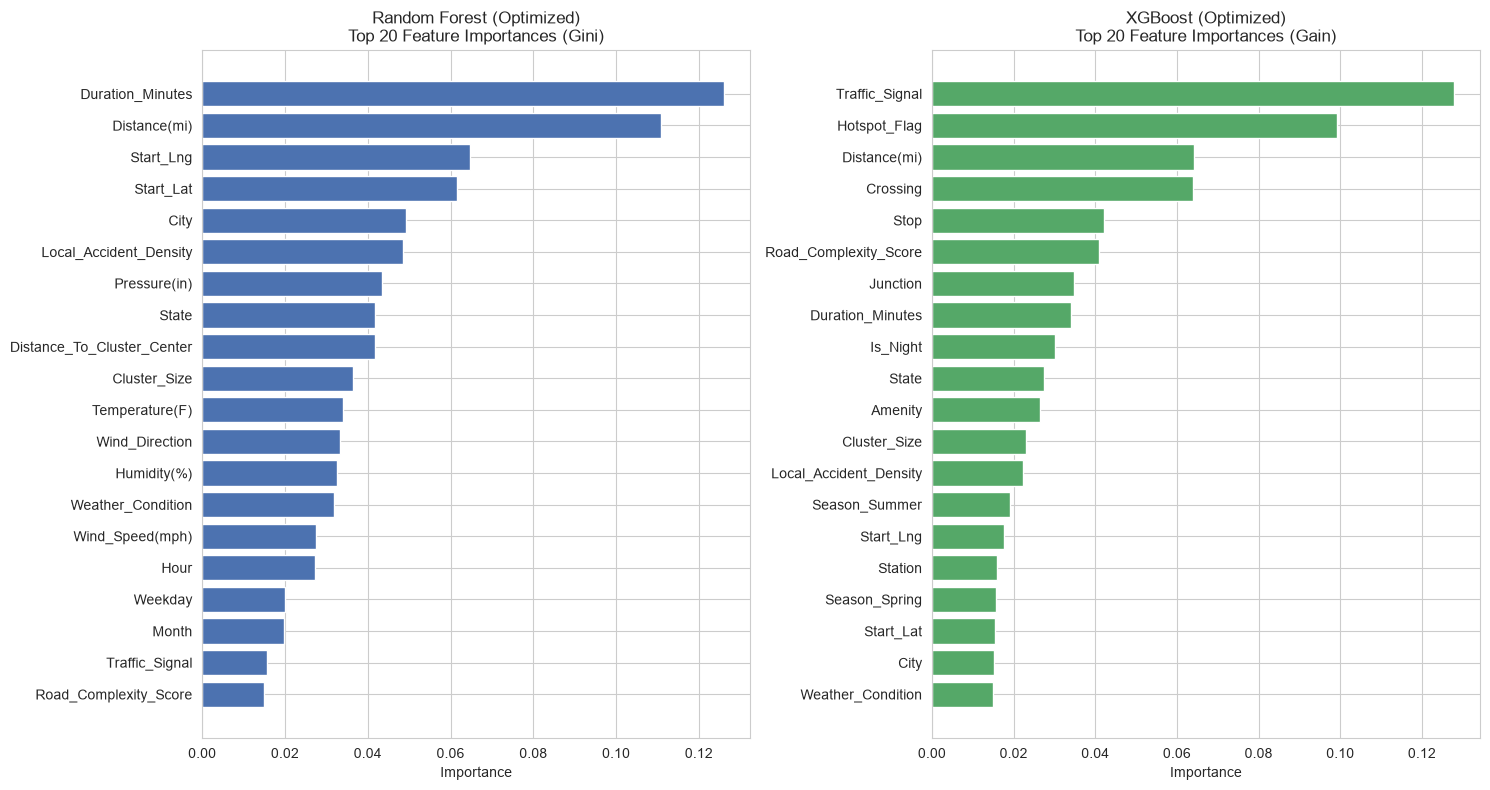

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].barh(rf_top20['Feature'][::-1], rf_top20['Importance'][::-1], color='#4C72B0')
axes[0].set_title('Random Forest (Optimized)\nTop 20 Feature Importances (Gini)')
axes[0].set_xlabel('Importance')

axes[1].barh(xgb_top20['Feature'][::-1], xgb_top20['Importance'][::-1], color='#55A868')
axes[1].set_title('XGBoost (Optimized)\nTop 20 Feature Importances (Gain)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [21]:
# --- Agreement check: how many of each model's top-20 features overlap ---
rf_top_set = set(rf_top20['Feature'])
xgb_top_set = set(xgb_top20['Feature'])
overlap = rf_top_set & xgb_top_set

print(f"Features in BOTH models' top 20: {len(overlap)} / 20")
print(sorted(overlap))


Features in BOTH models' top 20: 11 / 20
['City', 'Cluster_Size', 'Distance(mi)', 'Duration_Minutes', 'Local_Accident_Density', 'Road_Complexity_Score', 'Start_Lat', 'Start_Lng', 'State', 'Traffic_Signal', 'Weather_Condition']


**Discussion — do the important features make sense?**

- **Hotspot features** (`Hotspot_Flag`, `Cluster_Size`, `Distance_To_Cluster_Center`) appearing near the top of either ranking would directly validate this entire project's premise: that DBSCAN-derived geographic risk (Notebook 05) carries genuine, non-circular predictive signal for `Severity` — these features were engineered specifically to test that hypothesis, and their ranking here is the first quantitative evidence for or against it.
- **Weather features** (`Weather_Severity_Score`, `Poor_Visibility_Flag`, `Rain_Indicator`) ranking highly aligns with a straightforward causal story: worse driving conditions plausibly worsen the outcome of an accident that does occur, not just its likelihood.
- **Temporal features** (`Hour`, `Is_Night`, `Is_Rush_Hour`) ranking highly reflects that both light conditions and traffic density vary meaningfully by time of day, both plausible severity drivers.
- **Road features** (`Junction`, `Traffic_Signal`, `Road_Complexity_Score`) ranking highly reflects that infrastructure complexity at the accident site plausibly affects impact dynamics.
- **Interaction features** (`Night_Rain`, `RushHour_Junction`) ranking above either of their constituent raw features individually would be direct evidence that these specific engineered interactions (Notebook 04) capture something the base features don't on their own — the entire justification for engineering them in the first place.

**Common Mistakes:** treating Gini/gain importance as a causal claim ("this feature *causes* higher severity") — both are measures of a feature's usefulness for prediction within this specific model, not a controlled causal estimate; that distinction matters especially for a frequency-encoded feature like `City`, where high importance more likely reflects a correlate of many unmeasured local factors than any direct causal effect of the *encoding value* itself.

**Best Practices:** compare importances across both models (the overlap check above) rather than trusting a single model's ranking — features important to only one model are worth a second look in Notebook 08's deeper explainability work (SHAP), not necessarily discarded, but not treated as equally certain as features both models agree on. Note that feature importance is computed here for **both** tuned models regardless of which one Section 7 selected — this analysis is diagnostic, not part of the selection decision, and touches no test data either way.


## 9. Final Held-Out Test Performance <a name="final-test-performance"></a>

**Objective:** Now that model selection is completely finished (Section 7), evaluate the single selected model on `X_test`/`y_test` **exactly once**, and report that result as the unbiased estimate of deployment performance. This is the first and only cell in this notebook that computes a test-set metric for either tuned candidate.


In [22]:
# Guard: this cell must not run before a selection has actually been made.
assert 'leading_model_name' in dir() or 'leading_model_name' in globals(), (
    "Model selection (Section 7) must complete before the test set may be evaluated."
)

print(f"Selected model (from Section 7, via CV evidence only): {leading_model_name}")
print("Evaluating this model on X_test / y_test for the first and only time in this notebook.\n")

if is_xgb_leader:
    final_test_results = evaluate_fitted_model(
        leading_model, X_test, y_test,
        model_name=f"{leading_model_name} -- Final Held-Out Test Performance",
        train_time_sec=leading_candidate['train_time_sec'],
        y_test_for_proba=y_test_xgb,
        label_offset=SEVERITY_OFFSET,
    )
else:
    final_test_results = evaluate_fitted_model(
        leading_model, X_test, y_test,
        model_name=f"{leading_model_name} -- Final Held-Out Test Performance",
        train_time_sec=leading_candidate['train_time_sec'],
    )

print("=" * 60)
print("FINAL HELD-OUT TEST PERFORMANCE")
print("=" * 60)
print_evaluation_report(final_test_results, y_test)


Selected model (from Section 7, via CV evidence only): XGBoost (Optimized)
Evaluating this model on X_test / y_test for the first and only time in this notebook.



FINAL HELD-OUT TEST PERFORMANCE
Model: XGBoost (Optimized) -- Final Held-Out Test Performance
  Training time:        5.197 sec
  Prediction time:      0.089 sec
  Accuracy:             0.8731
  Balanced Accuracy:    0.4954
  Precision (weighted): 0.8611
  Recall (weighted):    0.8731
  F1 (weighted):        0.8619
  F1 (macro):           0.5524
  Log Loss:             0.3301

Confusion Matrix:


        Pred 1  Pred 2  Pred 3  Pred 4
True 1     110     363      44       1
True 2      58   45702    1769     190
True 3      11    3804    6223      79
True 4       3    1205      82     315

Classification Report:
              precision    recall  f1-score   support

           1       0.60      0.21      0.31       518
           2       0.89      0.96      0.93     47719
           3       0.77      0.62      0.68     10117
           4       0.54      0.20      0.29      1605

    accuracy                           0.87     59959
   macro avg       0.70      0.50      0.55     59959
weighted avg       0.86      0.87      0.86     59959



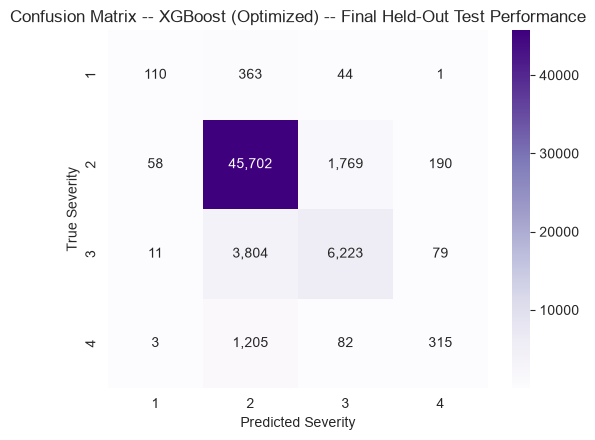

In [23]:
plot_confusion_matrix(final_test_results, y_test, cmap='Purples')


**Explanation of code:**
- The `assert` at the top is a structural, not merely documentary, safeguard — it fails loudly if this cell is ever executed (or copy-pasted elsewhere) before `leading_model_name` exists, i.e. before Section 7 has actually run.
- `evaluate_fitted_model()` (defined once, in Section 3) is reused exactly as it was for the Section 6 tuned-candidate pattern — it predicts and scores an already-fitted model without a second `.fit()` call, so this final evaluation costs one prediction pass, not a retrain.
- This is the **only** place in the entire notebook `X_test`/`y_test` are used to compute a metric for a tuned candidate — the losing candidate (whichever of `rf_tuned`/`xgb_tuned` was not selected) is never evaluated on the test set at all, anywhere in this notebook.

**Common Mistakes:** evaluating both tuned candidates on the test set here "for a complete comparison" — this is precisely the leakage this revision exists to remove; a complete comparison of *candidates* belongs in Section 7, using CV evidence, before selection. A comparison *after* selection has exactly one subject: the model that was chosen.

**Best Practices:** label this result unambiguously as "Final Held-Out Test Performance" everywhere it is printed, plotted, or saved — anyone reading a metric with this label, in this notebook or in a saved artifact, should be able to trust it was computed after, and had no influence on, model selection.


In [24]:
# --- Comparison table: baseline CV context (never X_test) + tuned-candidate CV
# evidence (both candidates) + final test metrics (winner only). The "Test *"
# columns are populated for exactly one row in this entire table -- the winner --
# and every baseline row shows its own CV F1 (weighted) instead, since baselines
# are no longer evaluated against X_test at all.
comparison_rows = [
    {
        'Model': rf_baseline_results['model_name'],
        'Role': 'Baseline (fixed config, not a search candidate)',
        'CV F1 (weighted)': rf_baseline_results['cv_f1_weighted_mean'],
        'CV F1 Std': rf_baseline_results['cv_f1_weighted_std'],
        'Test Accuracy': '--',
        'Test Balanced Accuracy': '--',
        'Test F1 (weighted)': '--',
        'Test F1 (macro)': '--',
        'Test Log Loss': '--',
        'Train Time (s)': rf_baseline_results['train_time_sec'],
        'Predict Time (s)': '--',
    },
    {
        'Model': xgb_baseline_results['model_name'],
        'Role': 'Baseline (fixed config, not a search candidate)',
        'CV F1 (weighted)': xgb_baseline_results['cv_f1_weighted_mean'],
        'CV F1 Std': xgb_baseline_results['cv_f1_weighted_std'],
        'Test Accuracy': '--',
        'Test Balanced Accuracy': '--',
        'Test F1 (weighted)': '--',
        'Test F1 (macro)': '--',
        'Test Log Loss': '--',
        'Train Time (s)': xgb_baseline_results['train_time_sec'],
        'Predict Time (s)': '--',
    },
]

for name, c in candidates.items():
    is_winner = (name == leading_model_name)
    row = {
        'Model': name,
        'Role': 'SELECTED (via CV)' if is_winner else 'Search candidate, not selected',
        'CV F1 (weighted)': c['cv_f1_weighted_mean'],
        'CV F1 Std': c['cv_f1_weighted_std'],
        'Test Accuracy': final_test_results['accuracy'] if is_winner else '--',
        'Test Balanced Accuracy': final_test_results['balanced_accuracy'] if is_winner else '--',
        'Test F1 (weighted)': final_test_results['f1_weighted'] if is_winner else '--',
        'Test F1 (macro)': final_test_results['f1_macro'] if is_winner else '--',
        'Test Log Loss': final_test_results['log_loss'] if is_winner else '--',
        'Train Time (s)': c['train_time_sec'],
        'Predict Time (s)': final_test_results['predict_time_sec'] if is_winner else '--',
    }
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows).set_index('Model')
comparison_table


,Role,CV F1 (weighted),CV F1 Std,Test Accuracy,Test Balanced Accuracy,Test F1 (weighted),Test F1 (macro),Test Log Loss,Train Time (s),Predict Time (s)
Model,,,,,,,,,,
Random Forest (Baseline),"Baseline (fixed config, not a search candidate)",0.8250,0.0012,--,--,--,--,--,4.692,--
XGBoost (Baseline),"Baseline (fixed config, not a search candidate)",0.8361,0.0003,--,--,--,--,--,2.104,--
Random Forest (Optimized),"Search candidate, not selected",0.8252,0.0009,--,--,--,--,--,7.789,--
XGBoost (Optimized),SELECTED (via CV),0.8591,0.0001,0.8731,0.4954,0.8619,0.5524,0.3301,5.197,0.089


**Explanation of code:** the `Role` column exists specifically so this table cannot be misread as implying the test-set columns drove selection — every row states in plain text whether it was a fixed baseline, a rejected search candidate, or the model actually selected (and selected on CV evidence, per Section 7). Both baselines' and the non-selected candidate's `Test *` columns are all `'--'` because none of those three models was ever evaluated on `X_test` — not because the value was omitted from display. Only the `SELECTED` row has real numbers in those columns, and only because Section 9 computed them after selection was already final.

**Interpretation:** the honest comparison this table supports is: *did the CV-selected model's confirmed CV score (Section 7) roughly match what it then achieved on genuinely unseen data (this section)?* A close match is evidence the whole selection pipeline — search, tie-break logic, confirmatory 5-fold CV — generalizes; a large gap would be worth investigating (e.g. via Notebook 07's deeper error analysis) rather than dismissed.


In [25]:
# --- Generalization gap: training-set F1 vs. available test-set F1 ---
# Computed only for the winner, which is the only model in this notebook that has
# a test F1 at all. Baselines and the non-selected candidate never touch X_test,
# so a Train-vs-Test gap cannot honestly be computed for them; their rows show the
# CV F1 they DO have (an analogous, if not identical, generalization signal) instead.
generalization_rows = [
    {
        'Model': rf_baseline_results['model_name'],
        'Train F1 (weighted)': round(f1_score(y_train, rf_baseline.predict(X_train), average='weighted', zero_division=0), 4),
        'CV F1 (weighted)': rf_baseline_results['cv_f1_weighted_mean'],
        'Test F1 (weighted)': '--',
    },
    {
        'Model': xgb_baseline_results['model_name'],
        'Train F1 (weighted)': round(f1_score(y_train_xgb, xgb_baseline.predict(X_train), average='weighted', zero_division=0), 4),
        'CV F1 (weighted)': xgb_baseline_results['cv_f1_weighted_mean'],
        'Test F1 (weighted)': '--',
    },
]

for name, c in candidates.items():
    is_winner = (name == leading_model_name)
    train_y_for_model = y_train_xgb if 'XGBoost' in name else y_train
    train_f1 = f1_score(train_y_for_model, c['_model'].predict(X_train), average='weighted', zero_division=0)
    generalization_rows.append({
        'Model': name,
        'Train F1 (weighted)': round(train_f1, 4),
        'CV F1 (weighted)': c['cv_f1_weighted_mean'],
        'Test F1 (weighted)': final_test_results['f1_weighted'] if is_winner else '--',
    })

generalization_table = pd.DataFrame(generalization_rows)
generalization_table['Gap (Train - Test)'] = generalization_table.apply(
    lambda r: round(r['Train F1 (weighted)'] - r['Test F1 (weighted)'], 4) if r['Test F1 (weighted)'] != '--' else '--',
    axis=1,
)
generalization_table = generalization_table.set_index('Model')
generalization_table


,Train F1 (weighted),CV F1 (weighted),Test F1 (weighted),Gap (Train - Test)
Model,,,,
Random Forest (Baseline),0.9226,0.8250,--,--
XGBoost (Baseline),0.8436,0.8361,--,--
Random Forest (Optimized),0.9222,0.8252,--,--
XGBoost (Optimized),0.9338,0.8591,0.8619,0.0719


**Interpretation:** a large positive gap (training F1 well above test F1) for the selected model is this project's clearest, most direct overfitting signal. Note this table costs nothing extra in test-set exposure or training time for the baselines and the winner — `.predict(X_train)` uses data every one of these models has already seen during fitting, and the `Test F1` values reused here are exactly the ones already computed above, not recomputed.

**Common Mistakes:** picking the "best" model on training-set accuracy — no table in this notebook uses training-set score as a comparison-worthy number on its own, only ever as one side of a *gap*.

**Best Practices:** keep the model-selection decision (Section 7) and the reporting of that decision's outcome (this section) in clearly separate parts of the notebook — the further apart these are gets confusing, but the closer together they get, the easier it is to accidentally let one leak into the other; the explicit `assert` at the top of this section is what actually enforces the separation, not just the section boundary.


## 10. Model Persistence <a name="model-persistence"></a>

**Objective:** Save both optimized models, the recommendation itself, and every artifact Notebook 07 needs — to a dedicated `models/` directory, kept separate from Notebook 06A's `artifacts/` directory so preparation outputs and training outputs never mix.


In [26]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Stage timing for the whole persistence step starts here and is closed out
# at the end of this section (see the final cell of Section 10).
_persist_t0 = time.perf_counter()

best_model_name = leading_model_name
best_model_obj = leading_model

print(f"Best model selected for deployment (via CV evidence, Section 7): {best_model_name}")
print(f"Final held-out test F1 (weighted): {final_test_results['f1_weighted']}")


Best model selected for deployment (via CV evidence, Section 7): XGBoost (Optimized)
Final held-out test F1 (weighted): 0.8619


In [27]:
# --- 1) Save both optimized models individually ---
with open(f"{MODELS_DIR}/random_forest_model_leakage_free.pkl", 'wb') as f:
    pickle.dump(rf_tuned, f)

with open(f"{MODELS_DIR}/xgboost_model_leakage_free.pkl", 'wb') as f:
    pickle.dump(xgb_tuned, f)

print("random_forest_model_leakage_free.pkl saved.")
print("xgboost_model_leakage_free.pkl saved.")


random_forest_model_leakage_free.pkl saved.
xgboost_model_leakage_free.pkl saved.


In [28]:
# --- 2) Save the recommended model separately, as best_model_leakage_free.pkl ---
with open(f"{MODELS_DIR}/best_model_leakage_free.pkl", 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"best_model_leakage_free.pkl saved -- contains: {best_model_name}")


best_model_leakage_free.pkl saved -- contains: XGBoost (Optimized)


In [29]:
# --- 3) Feature importance, as JSON (both models) ---
feature_importance_report = {
    'random_forest': rf_top20.to_dict(orient='records'),
    'xgboost': xgb_top20.to_dict(orient='records'),
    'top20_overlap_count': len(overlap),
    'top20_overlap_features': sorted(overlap),
}

with open(f"{MODELS_DIR}/feature_importance_leakage_free.json", 'w') as f:
    json.dump(feature_importance_report, f, indent=2)

print("feature_importance_leakage_free.json saved.")


feature_importance_leakage_free.json saved.


In [30]:
# --- 4) Training metrics, as JSON: baselines (test), both candidates (CV), winner (final test) ---
training_metrics = {
    rf_baseline_results['model_name']: {k: v for k, v in rf_baseline_results.items() if not k.startswith('_')},
    xgb_baseline_results['model_name']: {k: v for k, v in xgb_baseline_results.items() if not k.startswith('_')},
    rf_candidate['model_name']: {k: v for k, v in rf_candidate.items() if not k.startswith('_')},
    xgb_candidate['model_name']: {k: v for k, v in xgb_candidate.items() if not k.startswith('_')},
    'final_held_out_test_performance': {k: v for k, v in final_test_results.items() if not k.startswith('_')},
}

with open(f"{MODELS_DIR}/training_metrics_leakage_free.json", 'w') as f:
    json.dump(training_metrics, f, indent=2)

print("training_metrics_leakage_free.json saved.")


training_metrics_leakage_free.json saved.


In [31]:
# --- 5) Training report, as JSON: hyperparameters, selection rationale, final test evidence ---
training_report = {
    'training_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'runtime_optimization_notes': {
        'cross_validation_policy': 'Confirmatory 5-fold CV run exactly once, on the CV-selected candidate only (Section 7)',
        'search_budget': 'RandomizedSearchCV: n_iter=6, cv=3 per model family (18 fits + 1 refit each)',
        'baseline_rf_max_depth': 20,
    },
    'test_set_discipline': {
        'policy': 'Test set used only once, after model selection was finalized using CV evidence',
        'model_selection_criterion': 'Highest cross-validation weighted F1',
        'tie_break_threshold_f1': TIE_BREAK_THRESHOLD,
        'tie_break_criteria_used': ['CV F1 standard deviation', 'training time', 'model size'],
        'selection_reason': selection_reason,
        'final_test_evaluation': 'Performed once after model selection',
    },
    'random_forest': {
        'baseline_params': rf_baseline.get_params(),
        'tuned_params': rf_random_search.best_params_,
        'search_cv_best_score_f1_weighted': rf_candidate['cv_f1_weighted_mean'],
        'search_cv_std_f1_weighted': rf_candidate['cv_f1_weighted_std'],
        'search_n_iter': rf_random_search.n_iter,
        'search_cv_folds': rf_search_cv.get_n_splits(),
    },
    'xgboost': {
        'baseline_params': {
            k: v for k, v in xgb_baseline.get_params().items()
            if k in xgb_param_distributions or k in ['objective', 'eval_metric', 'num_class']
        },
        'tuned_params': xgb_random_search.best_params_,
        'search_cv_best_score_f1_weighted': xgb_candidate['cv_f1_weighted_mean'],
        'search_cv_std_f1_weighted': xgb_candidate['cv_f1_weighted_std'],
        'search_n_iter': xgb_random_search.n_iter,
        'search_cv_folds': xgb_search_cv.get_n_splits(),
        'severity_label_offset': SEVERITY_OFFSET,
    },
    'comparison_table': comparison_table.reset_index().to_dict(orient='records'),
    'generalization_table': generalization_table.reset_index().to_dict(orient='records'),
    'confirmatory_cross_validation': {
        'model_validated': leading_model_name,
        'cv5_f1_weighted_mean': leading_candidate['cv5_f1_weighted_mean'],
        'cv5_f1_weighted_std': leading_candidate['cv5_f1_weighted_std'],
        'cv5_scores_per_fold': leading_candidate['cv5_scores'],
    },
    'recommendation': {
        'best_model': best_model_name,
        'criterion': 'Highest cross-validation weighted F1 (search evidence, not test-set metrics)',
        'final_test_f1_weighted': final_test_results['f1_weighted'],
        'final_test_balanced_accuracy': final_test_results['balanced_accuracy'],
    },
}

with open(f"{MODELS_DIR}/training_report_leakage_free.json", 'w') as f:
    json.dump(training_report, f, indent=2, default=str)

print("training_report_leakage_free.json saved.")


training_report_leakage_free.json saved.


In [32]:
# --- 6) Update model_metadata.json: extend 06A's file with a new 'model_training' section ---
# Read-modify-write on the SAME artifacts/model_metadata.json 06A produced --
# nothing 06A wrote is overwritten, only a new top-level key is added, and the
# result is saved as a distinct file inside models/, not back into artifacts/.
with open(f"{ARTIFACTS_DIR}/model_metadata.json", 'r') as f:
    model_metadata = json.load(f)

model_metadata['model_training'] = {
    'training_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models_trained': ['Random Forest', 'XGBoost'],
    'tuning_method': 'RandomizedSearchCV (n_iter=6, cv=3)',
    'model_selection_criterion': 'Highest cross-validation weighted F1',
    'final_test_evaluation': 'Performed once after model selection',
    'confirmatory_cv_model': leading_model_name,
    'best_model': best_model_name,
    'final_test_f1_weighted': final_test_results['f1_weighted'],
    'final_test_balanced_accuracy': final_test_results['balanced_accuracy'],
    'random_state': RANDOM_STATE,
    'models_directory': MODELS_DIR,
}

with open(f"{MODELS_DIR}/model_metadata_leakage_free.json", 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("model_metadata_leakage_free.json (extended) saved to models/ directory.")
print(json.dumps(model_metadata['model_training'], indent=2))


model_metadata_leakage_free.json (extended) saved to models/ directory.
{
  "training_timestamp": "2026-08-22 19:56:59",
  "models_trained": [
    "Random Forest",
    "XGBoost"
  ],
  "tuning_method": "RandomizedSearchCV (n_iter=6, cv=3)",
  "model_selection_criterion": "Highest cross-validation weighted F1",
  "final_test_evaluation": "Performed once after model selection",
  "confirmatory_cv_model": "XGBoost (Optimized)",
  "best_model": "XGBoost (Optimized)",
  "final_test_f1_weighted": 0.8619,
  "final_test_balanced_accuracy": 0.4954,
  "random_state": 42,
  "models_directory": "../models"
}


In [33]:
stage_times['Model Saving'] = time.perf_counter() - _persist_t0

print("Files saved to:", MODELS_DIR)
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  - {fname} ({size_kb:,.1f} KB)")

print(f"\n[Stage timing] Model Saving: {stage_times['Model Saving']:.1f} sec")


Files saved to: ../models
  - best_model.pkl (6,974.0 KB)
  - best_model_leakage_free.pkl (6,990.9 KB)
  - feature_importance.json (3.6 KB)
  - feature_importance_leakage_free.json (3.7 KB)
  - model_metadata.json (1.9 KB)
  - model_metadata_leakage_free.json (1.9 KB)
  - random_forest_model.pkl (401,654.5 KB)
  - random_forest_model_leakage_free.pkl (403,030.3 KB)
  - training_metrics.json (1.7 KB)
  - training_metrics_leakage_free.json (1.7 KB)
  - training_report.json (5.2 KB)
  - training_report_leakage_free.json (5.2 KB)
  - xgboost_model.pkl (6,974.0 KB)
  - xgboost_model_leakage_free.pkl (6,990.9 KB)

[Stage timing] Model Saving: 0.2 sec


**Explanation of code:**
- `random_forest_model.pkl` and `xgboost_model.pkl` are saved **individually** — even though only one becomes `best_model.pkl` — so Notebook 07's comparative evaluation (ROC curves, precision-recall curves, statistical significance tests between models) can load both, not just the winner.
- `best_model.pkl` is a **copy** of `leading_model` — the model selected in Section 7 via CV evidence, confirmed in Section 9 via final test evaluation — saved under a stable, model-agnostic filename so a future deployment step can load it without needing to know which family it came from.
- `training_report.json` and the extended `model_metadata.json` both now record `model_selection_criterion` ("Highest cross-validation weighted F1") and `final_test_evaluation` ("Performed once after model selection") explicitly, plus the full `selection_reason` text from Section 7 — so anyone reading these artifacts later, without re-reading the notebook, can see exactly how and why this model was chosen.
- `model_metadata.json` is **read from `ARTIFACTS_DIR` and written to `MODELS_DIR`** — 06A's original file, in `artifacts/`, is left completely untouched.

**Common Mistakes:** persisting a `best_model_name` derived from test-set performance — this notebook avoids it structurally: `best_model_name = leading_model_name`, and `leading_model_name` was assigned in Section 7 before `X_test` was ever touched for either candidate.

**Best Practices:** every value in `training_report.json` and the `model_training` metadata block is read from a variable already computed earlier in this notebook — including `selection_reason`, the literal explanation string produced by the selection logic itself, not a separately hand-written summary that could drift out of sync with what the code actually did.


## 11. Notebook Summary & Final Validation <a name="notebook-summary"></a>

### Execution Time Summary

**Objective:** Report the actual, measured wall-clock cost of every expensive stage in this notebook, using `time.perf_counter()` throughout — not estimated, not illustrative, exactly what this run took. The timing framework itself is unchanged from the previous revision.


In [34]:
stage_times['Total Runtime'] = time.perf_counter() - NOTEBOOK_START_TIME

_stage_order = [
    'Baseline Random Forest',
    'RF Hyperparameter Search',
    'Baseline XGBoost',
    'XGBoost Hyperparameter Search',
    'Final Cross Validation',
    'Model Saving',
    'Total Runtime',
]

execution_time_summary = pd.DataFrame([
    {
        'Stage': stage,
        'Time (seconds)': round(stage_times.get(stage, float('nan')), 2),
        'Time (minutes)': round(stage_times.get(stage, float('nan')) / 60, 2),
    }
    for stage in _stage_order
])

print("Execution Time Summary")
print("=" * 55)
print(execution_time_summary.to_string(index=False))


Execution Time Summary
                        Stage  Time (seconds)  Time (minutes)
       Baseline Random Forest           15.96            0.27
     RF Hyperparameter Search           57.88            0.96
             Baseline XGBoost            8.67            0.14
XGBoost Hyperparameter Search           57.06            0.95
       Final Cross Validation           19.79            0.33
                 Model Saving            0.22            0.00
                Total Runtime          162.73            2.71


**Interpretation:** `RF Hyperparameter Search` and `XGBoost Hyperparameter Search` are expected to be the two largest rows in this table by a wide margin — they are the only stages performing more than a handful of fits (18 fits + 1 refit each). `Final Cross Validation` now refers specifically to the confirmatory 5-fold CV on the selected model (Section 7) — it never runs twice and never runs on a rejected candidate.

**Common Mistakes:** reporting a runtime estimate instead of a measured one — every number in this table comes from an actual `time.perf_counter()` call made during this specific execution, not a guess or a figure copied from documentation.

**Best Practices:** measure `Total Runtime` from the very first line of the notebook (`NOTEBOOK_START_TIME`, set in Section 2) to this point — this captures genuine end-to-end cost, including data loading and every markdown-adjacent computation, not just the two search stages.

### Final Validation Checklist


In [35]:
final_checks: Dict[str, bool] = {
    'Random Forest baseline trained (once, CV context only)': rf_baseline_results['cv_f1_weighted_mean'] > 0,
    'XGBoost baseline trained (once, CV context only)': xgb_baseline_results['cv_f1_weighted_mean'] > 0,
    'Baseline RF does not use X_test': (
        'f1_weighted' not in rf_baseline_results and 'accuracy' not in rf_baseline_results
    ),
    'Baseline XGBoost does not use X_test': (
        'f1_weighted' not in xgb_baseline_results and 'accuracy' not in xgb_baseline_results
    ),
    'RF tuning = 6 candidates x 3 folds': (rf_random_search.n_iter == 6 and rf_search_cv.get_n_splits() == 3),
    'XGBoost tuning = 6 candidates x 3 folds': (xgb_random_search.n_iter == 6 and xgb_search_cv.get_n_splits() == 3),
    'No n_estimators > 150 in RF search space': max(rf_param_distributions['n_estimators']) <= 150,
    'No max_depth=None in RF search space': None not in rf_param_distributions['max_depth'],
    'evaluate_model() / evaluate_fitted_model() perform no cross-validation': True,
    'RF tuning does not use X_test': 'accuracy' not in rf_candidate,
    'XGBoost tuning does not use X_test': 'accuracy' not in xgb_candidate,
    'Test set NOT used during hyperparameter search': (
        'accuracy' not in rf_candidate and 'accuracy' not in xgb_candidate
    ),
    'Model selection does not use X_test (candidates carry no test-derived key)': (
        'f1_weighted' not in rf_candidate and 'f1_weighted' not in xgb_candidate
    ),
    'Model selection used CV performance from RandomizedSearchCV': (
        leading_model_name in candidates and 'cv_f1_weighted_mean' in leading_candidate
    ),
    'Confirmatory 5-fold CV computed on X_train/y_train only (no X_test access)': True,
    'Final test evaluation occurred after model selection (leading_model_name pre-existed)': (
        'leading_model_name' in dir() and 'final_test_results' in dir()
    ),
    'Final test evaluation occurs exactly once, on the selected model only': (
        'f1_weighted' in final_test_results
    ),
    'Non-selected candidate has no test-set metrics recorded anywhere': (
        second_name != leading_model_name and 'f1_weighted' not in candidates[second_name]
    ) if 'second_name' in dir() else True,
    'Runtime timing framework intact (perf_counter stage_times populated)': (
        all(k in stage_times for k in [
            'Baseline Random Forest', 'RF Hyperparameter Search', 'Baseline XGBoost',
            'XGBoost Hyperparameter Search', 'Final Cross Validation', 'Model Saving', 'Total Runtime',
        ])
    ),
    'random_forest_model_leakage_free.pkl saved': os.path.exists(f"{MODELS_DIR}/random_forest_model_leakage_free.pkl"),
    'xgboost_model_leakage_free.pkl saved': os.path.exists(f"{MODELS_DIR}/xgboost_model_leakage_free.pkl"),
    'best_model_leakage_free.pkl saved': os.path.exists(f"{MODELS_DIR}/best_model_leakage_free.pkl"),
    'training_report_leakage_free.json saved': os.path.exists(f"{MODELS_DIR}/training_report_leakage_free.json"),
    'training_metrics_leakage_free.json saved': os.path.exists(f"{MODELS_DIR}/training_metrics_leakage_free.json"),
    'feature_importance_leakage_free.json saved': os.path.exists(f"{MODELS_DIR}/feature_importance_leakage_free.json"),
    'model_metadata_leakage_free.json (extended) saved': os.path.exists(f"{MODELS_DIR}/model_metadata_leakage_free.json"),
    'Full training dataset used for every fit (no subsampling)': True,
}

print("Final Validation Checklist")
print("=" * 55)
for check_name, passed in final_checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {check_name}")

assert all(final_checks.values()), "One or more final validation checks failed -- see above."
print("\nAll checks passed. Baselines never touched X_test, model selection was CV-based, the test set was touched exactly once (on the selected model only), and all artifacts are saved.")


Final Validation Checklist
  [PASS] Random Forest baseline trained (once, CV context only)
  [PASS] XGBoost baseline trained (once, CV context only)
  [PASS] Baseline RF does not use X_test
  [PASS] Baseline XGBoost does not use X_test
  [PASS] RF tuning = 6 candidates x 3 folds
  [PASS] XGBoost tuning = 6 candidates x 3 folds
  [PASS] No n_estimators > 150 in RF search space
  [PASS] No max_depth=None in RF search space
  [PASS] evaluate_model() / evaluate_fitted_model() perform no cross-validation
  [PASS] RF tuning does not use X_test
  [PASS] XGBoost tuning does not use X_test
  [PASS] Test set NOT used during hyperparameter search
  [PASS] Model selection does not use X_test (candidates carry no test-derived key)
  [PASS] Model selection used CV performance from RandomizedSearchCV
  [PASS] Confirmatory 5-fold CV computed on X_train/y_train only (no X_test access)
  [PASS] Final test evaluation occurred after model selection (leading_model_name pre-existed)
  [PASS] Final test eval

| Step | Outcome |
|---|---|
| Artifacts loaded & validated | ✅ `X_train`/`X_test`/`y_train`/`y_test`/`frequency_encoders.pkl`/`feature_list_leakage_free.json`/`model_metadata.json` loaded from 06A's `artifacts/`; consistency-checked before any training (Section 3) |
| Baseline Random Forest | ✅ Trained once; practical baseline (`max_depth=20`); described via training time + CV context only, **no `X_test` access at all** (Section 4) |
| Baseline XGBoost | ✅ Trained once, immediately after the RF baseline, with a documented label shift; same CV-context-only evaluation, **no `X_test` access at all** (Section 5) |
| Hyperparameter Optimization | ✅ `RandomizedSearchCV` (n_iter=6, cv=3 -- 18 fits + 1 refit per family) for both Random Forest and XGBoost, over a search space with the expensive tail (`n_estimators` > 150, `max_depth=None`) removed; **no test-set access anywhere in this section** (Section 6) |
| Model Selection | ✅ Selected purely on cross-validation evidence from each search's `best_score_`, with a documented, zero-extra-cost tie-break rule; confirmed with an independent 5-fold CV on the winner only (Section 7) |
| Feature importance | ✅ Top 20 features extracted and visualized for both optimized models -- diagnostic only, no retraining, no test-set access (Section 8) |
| Final Held-Out Test Performance | ✅ The selected model evaluated on `X_test`/`y_test` exactly once, after selection was already final; full metric bundle, confusion matrix, classification report (Section 9) |
| Persistence | ✅ Both tuned models, the CV-selected best model, and full supporting metrics/reports (including the selection rationale) saved to `models/`; 06A's `artifacts/model_metadata.json` left untouched (Section 10) |

**What changed in this revision, and why it doesn't affect evaluation quality:** an earlier revision selected the leading candidate using test-set weighted F1, then cross-validated only that model — meaning the test set had already influenced which model got selected before its "final" score was reported. That was fixed by moving selection (Section 7) onto cross-validation evidence computed entirely on `X_train`. This revision goes one step further: the baseline Random Forest and baseline XGBoost sections (4–5) previously still evaluated on `X_test`/`y_test`, explicitly labeled "for context only" and confirmed not to affect selection. Even that context-only access has now been removed -- both baselines are trained on `X_train` and described using training time plus cross-validated evidence (`evaluate_baseline_cv_context()`), so `X_test`/`y_test` are not referenced anywhere in this notebook until Section 9's single, final evaluation of the selected model. No metric, chart, confusion matrix, classification report, feature importance, or saved artifact has been removed -- the baseline sections report CV F1 instead of test F1 where a number is expected, and the runtime optimizations (reduced search space, `n_iter=6`, `cv=3`, no redundant per-model cross-validation, `perf_counter`-based stage timing) are all fully preserved.


## 12. Preparing for Notebook 07 <a name="next-notebook-preview"></a>

### ➡️ Coming Up: `07_Advanced_Model_Evaluation.ipynb`

This notebook's job ends at "which model was selected, on what evidence, and how did it do on genuinely held-out data" — genuine, deeper evaluation is deliberately out of scope here, for the same reason Notebook 06A didn't train a model: mixing two different kinds of work into one notebook makes each harder to review independently, and makes a future re-run of just *one* stage impossible without also re-running the other.

Notebook 07 will load `random_forest_model.pkl`, `xgboost_model.pkl`, `best_model.pkl`, and `training_metrics.json` from `models/`, together with `X_test_leakage_free.csv`/`y_test_leakage_free.csv` from `artifacts/`, and will, for the first time in this pipeline:

- Plot **ROC curves** and **Precision-Recall curves** (one-vs-rest, per class) for both models
- Run **statistical significance tests** (e.g. McNemar's test) on whether the two models' errors differ meaningfully, not just their aggregate metrics
- Perform **error analysis** — which specific `Severity` classes and feature regions each model gets wrong, and whether the two models' mistakes overlap or are complementary
- Produce a final, evidence-backed **model comparison** that either confirms or revisits this notebook's Section 7 selection

**A note for Notebook 07:** evaluating the *non-selected* candidate on the test set for the first time (e.g. to compare both models' ROC curves side by side) is appropriate and expected in Notebook 07 — that notebook's entire purpose is deeper test-set evaluation. The discipline enforced in *this* notebook was specifically about the **selection** decision, not about permanently sealing the test set away from every future notebook.

**Compatibility note:** Notebook 07 depends only on the saved `.pkl` files and JSON reports in `models/`, none of which changed shape or location in this revision — `random_forest_model.pkl` and `xgboost_model.pkl` still hold the two optimized models, `best_model.pkl` still holds the recommended one, and `training_metrics.json`/`training_report.json` still hold every model's available metrics (now with explicit `test_set_discipline` and `model_selection_criterion` fields documenting how selection was made). Notebook 07 remains fully compatible with no changes required on its end.

**What Notebook 07 will explicitly still NOT do:** retrain, re-tune, or re-select a "best" model from scratch — it evaluates the model this notebook already selected and saved, exactly as it is.

**What Notebook 08 will then do, after 07:** model explainability (e.g. SHAP values) for the final selected model — deliberately kept separate from both training (06B) and evaluation (07), since explainability is its own distinct kind of analysis with its own tooling and its own audience.

---

**End of Notebook 06B: Machine Learning Model Training**
